In [ ]:
import pandas as pd

# Leer archivos
countries = pd.read_csv("countries.csv")
holidays = pd.read_csv("global_holidays.csv")
passengers = pd.read_csv("monthly_passengers.csv")

# --- Unir datasets ---
# 1. holidays + passengers (por ISO3, año, mes)
holidays['Year'] = pd.to_datetime(holidays['Date']).dt.year
holidays['Month'] = pd.to_datetime(holidays['Date']).dt.month

holidays_passengers = pd.merge(
    passengers,
    holidays,
    on=['ISO3','Year','Month'],
    how='left'
)

# 2. Agregar info de países
full_df = pd.merge(
    holidays_passengers,
    countries[['alpha_3','name']],
    left_on='ISO3', right_on='alpha_3',
    how='left'
)

# --- Explorar ---
print(full_df.shape)
print(full_df.head())
print(full_df.info())

(16854, 13)
  ISO3  Year  Month  Total  Domestic  International  Total_OS ADM_name  \
0  ALB  2010      1    NaN       NaN            NaN   117.350  Albania   
1  ALB  2010      1    NaN       NaN            NaN   117.350  Albania   
2  ALB  2010      2    NaN       NaN            NaN    86.535  Albania   
3  ALB  2010      3    NaN       NaN            NaN   103.795  Albania   
4  ALB  2010      3    NaN       NaN            NaN   103.795  Albania   

         Date                    Name            Type alpha_3     name  
0  2010-01-01          New Year's Day  Public holiday     ALB  Albania  
1  2010-01-02  New Year's Day (Day 2)  Public holiday     ALB  Albania  
2  2010-02-14         Valentine's Day      Observance     ALB  Albania  
3  2010-03-08            Mothers' Day      Observance     ALB  Albania  
4  2010-03-14              Summer Day  Public holiday     ALB  Albania  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16854 entries, 0 to 16853
Data columns (total 13 column

In [ ]:
# Crear variable "holiday_count" = número de feriados en ese mes/país
holiday_monthly = holidays.groupby(['ISO3','Year','Month']).size().reset_index(name='holiday_count')

# Juntar con pasajeros
df = pd.merge(passengers, holiday_monthly, on=['ISO3','Year','Month'], how='left')

# Rellenar NaN (meses sin feriados) con 0
df['holiday_count'] = df['holiday_count'].fillna(0)

# Agregar nombre de país
df = pd.merge(df, countries[['alpha_3','name']], left_on='ISO3', right_on='alpha_3', how='left')

print(df.head())
print(df.info())

  ISO3  Year  Month  Total  Domestic  International  Total_OS  holiday_count  \
0  ALB  2010      1    NaN       NaN            NaN   117.350            2.0   
1  ALB  2010      2    NaN       NaN            NaN    86.535            1.0   
2  ALB  2010      3    NaN       NaN            NaN   103.795            3.0   
3  ALB  2010      4    NaN       NaN            NaN   102.038            8.0   
4  ALB  2010      5    NaN       NaN            NaN   109.037            1.0   

  alpha_3     name  
0     ALB  Albania  
1     ALB  Albania  
2     ALB  Albania  
3     ALB  Albania  
4     ALB  Albania  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7242 entries, 0 to 7241
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ISO3           7242 non-null   object 
 1   Year           7242 non-null   int64  
 2   Month          7242 non-null   int64  
 3   Total          3955 non-null   float64
 4   Domestic       32

In [ ]:
import pandas as pd
import numpy as np

# === Cargar ===
monthly = pd.read_csv("monthly_passengers.csv")
holidays = pd.read_csv("global_holidays.csv")
countries = pd.read_csv("countries.csv")

# === Normalizar llaves y fechas ===
monthly['ISO3'] = monthly['ISO3'].astype(str).str.strip().str.upper()
holidays['ISO3'] = holidays['ISO3'].astype(str).str.strip().str.upper()
countries['alpha_3'] = countries['alpha_3'].astype(str).str.strip().str.upper()

holidays['Date'] = pd.to_datetime(holidays['Date'], errors='coerce')
holidays['Year'] = holidays['Date'].dt.year
holidays['Month'] = holidays['Date'].dt.month

monthly['date'] = pd.to_datetime(dict(year=monthly['Year'], month=monthly['Month'], day=1))

# === Pasajeros "mejor disponible" ===
monthly['Passengers'] = (
    monthly['Total']
      .combine_first(monthly['Total_OS'])
      .combine_first(monthly[['Domestic','International']].sum(axis=1, min_count=1))
)

# === Agregar feriados por país-mes ===
holiday_counts = (
    holidays.groupby(['ISO3','Year','Month','Type'], as_index=False)
            .agg(holidays_count=('Date','nunique'))
)

holiday_pivot = (
    holiday_counts.pivot_table(index=['ISO3','Year','Month'], columns='Type',
                               values='holidays_count', fill_value=0, aggfunc='sum')
                 .reset_index()
)

holiday_pivot['holidays_total'] = holiday_pivot.drop(columns=['ISO3','Year','Month']).sum(axis=1)

# Tipos esperados (si no existen, agrégalos como 0)
expected_types = [
    "Half-day holiday","Local holiday","Local observance","Observance",
    "Public holiday","Special holiday","Working day (replacement)"
]
for t in expected_types:
    if t not in holiday_pivot.columns:
        holiday_pivot[t] = 0

# === Merge maestro ===
base = (
    monthly
    .merge(countries, left_on='ISO3', right_on='alpha_3', how='left', suffixes=('','_country'))
    .merge(holiday_pivot, on=['ISO3','Year','Month'], how='left')
)

# Rellenar feriados nulos con 0
holiday_cols = ['holidays_total'] + [c for c in expected_types if c in base.columns]
base[holiday_cols] = base[holiday_cols].fillna(0)

# === Métricas MoM / YoY y desviación estacional ===
base = base.sort_values(['ISO3','date'])
base['mom_change_pct'] = base.groupby('ISO3')['Passengers'].pct_change(1)
base['yoy_change_pct'] = base.groupby('ISO3')['Passengers'].pct_change(12)

seasonal_baseline = base.groupby(['ISO3','Month'])['Passengers'].mean().rename('seasonal_expected')
base = base.merge(seasonal_baseline, on=['ISO3','Month'], how='left')
base['delta_vs_seasonal_pct'] = (base['Passengers'] - base['seasonal_expected']) / base['seasonal_expected']

# === Guardar para BI / análisis ===
base.to_csv("merged_monthly_passengers_holidays.csv", index=False)


/tmp/ipython-input-202281871.py:63: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  base['mom_change_pct'] = base.groupby('ISO3')['Passengers'].pct_change(1)
/tmp/ipython-input-202281871.py:64: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  base['yoy_change_pct'] = base.groupby('ISO3')['Passengers'].pct_change(12)


Dataset usado: merged
(7242, 27)
  ISO3  Year  Month  Total  Domestic  International  Total_OS        date  \
0  ALB  2010      1    NaN       NaN            NaN   117.350  2010-01-01   
1  ALB  2010      2    NaN       NaN            NaN    86.535  2010-02-01   
2  ALB  2010      3    NaN       NaN            NaN   103.795  2010-03-01   

   Passengers alpha_2  ... Local observance  Observance Public holiday  \
0     117.350      AL  ...              0.0         0.0            2.0   
1      86.535      AL  ...              0.0         1.0            0.0   
2     103.795      AL  ...              0.0         1.0            2.0   

  Special holiday Working day (replacement)  holidays_total  mom_change_pct  \
0             0.0                       0.0             2.0             NaN   
1             0.0                       0.0             1.0       -0.262591   
2             0.0                       0.0             3.0        0.199457   

   yoy_change_pct  seasonal_expected  delta_

,column,null_count,null_pct,dtype
14,common_name,7051,0.9736,object
4,Domestic,3950,0.5454,float64
5,International,3395,0.4688,float64
3,Total,3287,0.4539,float64
13,official_name,1524,0.2104,object
24,yoy_change_pct,1074,0.1483,float64
6,Total_OS,648,0.0895,float64
23,mom_change_pct,90,0.0124,float64
10,alpha_3,88,0.0122,object
9,alpha_2,88,0.0122,object



Nulos en columnas clave:


,column,null_count,null_pct,dtype
8,Passengers,5,0.0007,float64
2,Month,0,0.0000,int64
0,ISO3,0,0.0000,object
1,Year,0,0.0000,int64
18,Observance,0,0.0000,float64
19,Public holiday,0,0.0000,float64
22,holidays_total,0,0.0000,float64



Top países con más nulos en Passengers:


,ISO3,null_rate_Passengers
16,CHN,0.041667
0,ALB,0.000000
2,ARG,0.000000
3,ARM,0.000000
4,AUS,0.000000
5,AUT,0.000000
6,BEL,0.000000
7,BGR,0.000000
8,BHR,0.000000
1,ARE,0.000000



Top países con más nulos en holidays_total:


,ISO3,null_rate_holidays_total
0,ALB,0.0
1,ARE,0.0
2,ARG,0.0
3,ARM,0.0
4,AUS,0.0
5,AUT,0.0
6,BEL,0.0
7,BGR,0.0
8,BHR,0.0
9,BIH,0.0


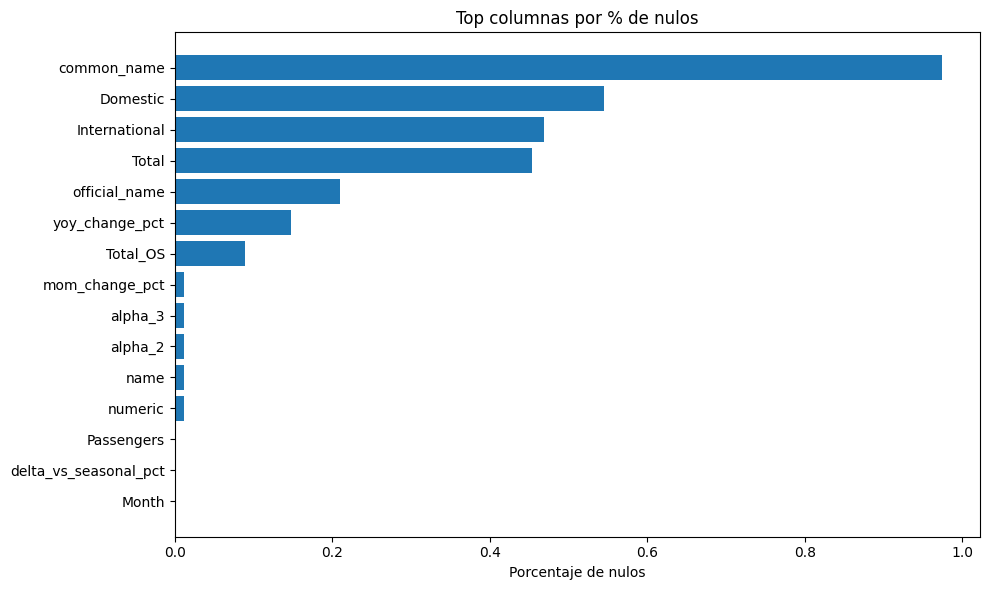

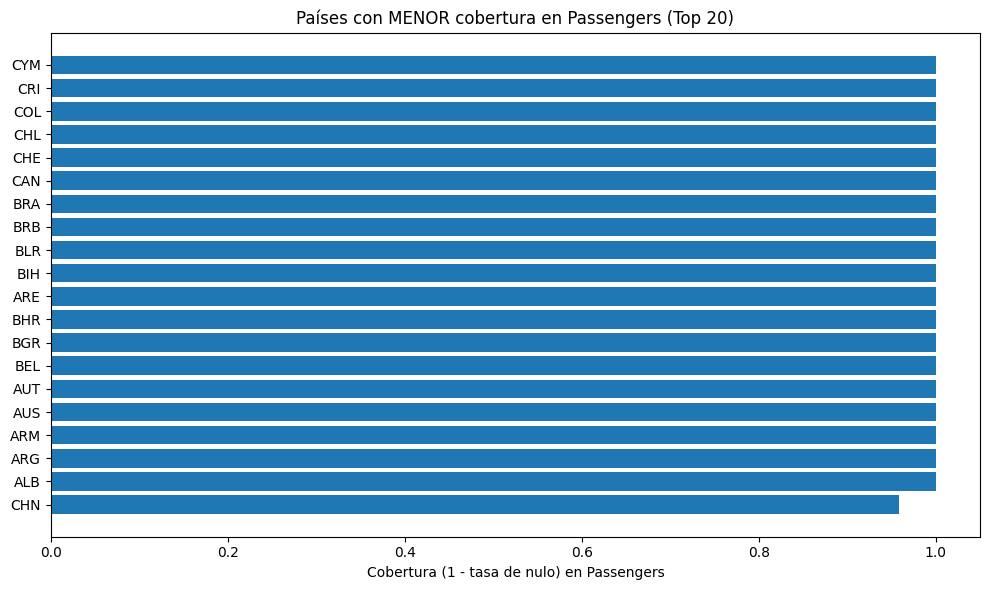


Posibles duplicados por llave (ISO3,Year,Month):


,ISO3,Year,Month,rows


In [ ]:
# ============================
# Análisis de Nulos - DataRush
# ============================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# ---------- Config ----------
# Si ya generaste el archivo integrado, actívalo:
USE_MERGED = True  # <-- pon True si ya tienes 'merged_monthly_passengers_holidays.csv'
MERGED_PATH = "merged_monthly_passengers_holidays.csv"

# Rutas originales (ajústalas si están en otra carpeta)
PATH_MONTHLY   = "monthly_passengers.csv"
PATH_HOLIDAYS  = "global_holidays.csv"
PATH_COUNTRIES = "countries.csv"

# Carpeta de salidas
OUT_DIR = "reports_nulos"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Funciones útiles ----------
def null_summary(df: pd.DataFrame, name: str):
    """Devuelve resumen de nulos: conteo, porcentaje y tipos dtypes."""
    total = df.shape[0]
    s_count = df.isna().sum()
    s_pct   = (s_count / total).round(4)
    dtypes  = df.dtypes.astype(str)
    out = pd.DataFrame({
        "column": df.columns,
        "null_count": s_count.values,
        "null_pct": s_pct.values,
        "dtype": [dtypes[c] for c in df.columns]
    }).sort_values("null_pct", ascending=False)
    out.to_csv(f"{OUT_DIR}/nulls_by_column__{name}.csv", index=False)
    return out

def barplot_top_nulls(summary_df: pd.DataFrame, title: str, top=15):
    """Barplot simple de las columnas con mayor % de nulos."""
    topdf = summary_df.head(top)
    plt.figure(figsize=(10, 6))
    plt.barh(topdf["column"], topdf["null_pct"])
    plt.gca().invert_yaxis()
    plt.xlabel("Porcentaje de nulos")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Carga de datos ----------
if USE_MERGED and os.path.exists(MERGED_PATH):
    base = pd.read_csv(MERGED_PATH)
    dataset_used = "merged"
else:
    # Cargar originales
    monthly   = pd.read_csv(PATH_MONTHLY)
    holidays  = pd.read_csv(PATH_HOLIDAYS)
    countries = pd.read_csv(PATH_COUNTRIES)

    # Normalizar llaves
    monthly['ISO3']  = monthly['ISO3'].astype(str).str.strip().str.upper()
    holidays['ISO3'] = holidays['ISO3'].astype(str).str.strip().str.upper()
    countries['alpha_3'] = countries['alpha_3'].astype(str).str.strip().str.upper()

    # Fechas
    holidays['Date'] = pd.to_datetime(holidays['Date'], errors='coerce')
    holidays['Year'] = holidays['Date'].dt.year
    holidays['Month'] = holidays['Date'].dt.month
    monthly['date'] = pd.to_datetime(dict(year=monthly['Year'], month=monthly['Month'], day=1))

    # Pasajeros "mejor disponible"
    monthly['Passengers'] = (
        monthly['Total']
          .combine_first(monthly['Total_OS'])
          .combine_first(monthly[['Domestic','International']].sum(axis=1, min_count=1))
    )

    # Agregación de feriados por país-mes
    holiday_counts = (
        holidays.groupby(['ISO3','Year','Month','Type'], as_index=False)
                .agg(holidays_count=('Date','nunique'))
    )
    holiday_pivot = (
        holiday_counts.pivot_table(index=['ISO3','Year','Month'],
                                   columns='Type',
                                   values='holidays_count',
                                   fill_value=0,
                                   aggfunc='sum')
                     .reset_index()
    )
    # Total de feriados (todas las clases)
    non_idx = [c for c in holiday_pivot.columns if c not in ['ISO3','Year','Month']]
    holiday_pivot['holidays_total'] = holiday_pivot[non_idx].sum(axis=1)

    # Merge maestro
    base = (
        monthly
        .merge(countries, left_on='ISO3', right_on='alpha_3', how='left', suffixes=('','_country'))
        .merge(holiday_pivot, on=['ISO3','Year','Month'], how='left')
    )

    # Rellenar feriados faltantes con 0
    feriado_cols = [c for c in base.columns if c not in monthly.columns and c not in countries.columns]
    base[feriado_cols] = base[feriado_cols].fillna(0)

    dataset_used = "built_from_raw"
    base.to_csv(MERGED_PATH, index=False)  # lo dejamos guardado por si lo necesitas

print(f"Dataset usado: {dataset_used}")
print(base.shape)
print(base.head(3))

# ---------- Resumen de nulos general ----------
summary_all = null_summary(base, "merged")
display(summary_all.head(20))

# ---------- Enfoque en columnas clave ----------
cols_key = [c for c in ["ISO3","Year","Month","Passengers","holidays_total","Public holiday","Observance"] if c in base.columns]
summary_key = summary_all[summary_all["column"].isin(cols_key)]
print("\nNulos en columnas clave:")
display(summary_key)

# ---------- Nulos por país (ej. Passengers / holidays_total) ----------
def nulls_by_country(df: pd.DataFrame, col: str):
    tmp = (df.assign(is_null=df[col].isna())
             .groupby("ISO3", dropna=False)["is_null"]
             .mean()
             .reset_index()
             .rename(columns={"is_null": f"null_rate_{col}"}))
    return tmp.sort_values(f"null_rate_{col}", ascending=False)

cols_focus = [c for c in ["Passengers","holidays_total"] if c in base.columns]
out_country_list = []
for c in cols_focus:
    nc = nulls_by_country(base, c)
    out_country_list.append(nc)
    nc.to_csv(f"{OUT_DIR}/null_rate_by_country__{c}.csv", index=False)
    print(f"\nTop países con más nulos en {c}:")
    display(nc.head(15))

# ---------- Gráficas rápidas ----------
# 1) Top columnas con mayor % de nulos
barplot_top_nulls(summary_all, "Top columnas por % de nulos", top=15)

# 2) Si quieres ver cobertura por país en Passengers (1 - null_rate):
if "Passengers" in base.columns:
    cov = nulls_by_country(base, "Passengers")
    cov["coverage_Passengers"] = 1 - cov["null_rate_Passengers"]
    cov_sorted = cov.sort_values("coverage_Passengers", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(cov_sorted["ISO3"].head(20), cov_sorted["coverage_Passengers"].head(20))
    plt.xlabel("Cobertura (1 - tasa de nulo) en Passengers")
    plt.title("Países con MENOR cobertura en Passengers (Top 20)")
    plt.tight_layout()
    plt.show()

# ---------- Extras útiles ----------
# Duplicados por llave país-mes (detección rápida)
key_cols = [c for c in ["ISO3","Year","Month"] if c in base.columns]
if key_cols:
    dup_mask = base.duplicated(subset=key_cols, keep=False)
    dups = base.loc[dup_mask, key_cols].value_counts().reset_index(name="rows")
    dups.to_csv(f"{OUT_DIR}/potential_duplicates__{'-'.join(key_cols)}.csv", index=False)
    print("\nPosibles duplicados por llave (ISO3,Year,Month):")
    display(dups.head(20))
else:
    print("\n(No se encontraron columnas clave ISO3/Year/Month para revisar duplicados)")


In [ ]:
# ============================
# Limpieza e imputación de nulos (DataRush)
# ============================
import pandas as pd
import numpy as np

# --- 1) Cargar ---
BASE_PATH = "merged_monthly_passengers_holidays.csv"  # ajusta si lo guardaste con otro nombre
df = pd.read_csv(BASE_PATH, parse_dates=["date"])

# --- 2) Reporte de nulos (antes) ---
def report_nulls(d, label):
    s = d.isna().mean().sort_values(ascending=False)
    print(f"\n--- NULLS ({label}) ---")
    print(s[s>0].head(25))

report_nulls(df[["ISO3","Year","Month","Passengers","holidays_total",
                 "mom_change_pct","yoy_change_pct","seasonal_expected",
                 "Total","Domestic","International","Total_OS"]], "ANTES")

# --- 3) Imputación de Passengers ---
# Asegurar orden temporal
df = df.sort_values(["ISO3","date"])

# Paso 1: usar seasonal_expected
df["Passengers_imputed"] = df["Passengers"]
mask1 = df["Passengers_imputed"].isna() & df["seasonal_expected"].notna()
df.loc[mask1, "Passengers_imputed"] = df.loc[mask1, "seasonal_expected"]

# Paso 2: usar mediana por país (si aún hay NaN)
med_by_ctry = df.groupby("ISO3")["Passengers"].median()
mask2 = df["Passengers_imputed"].isna()
df.loc[mask2, "Passengers_imputed"] = df.loc[mask2, "ISO3"].map(med_by_ctry)

# Paso 3: drop final si quedara algo
before_drop = df.shape[0]
df = df[~df["Passengers_imputed"].isna()].copy()
after_drop = df.shape[0]
print(f"\nFilas eliminadas por no poder imputar Passengers: {before_drop - after_drop}")

# Reemplazar columna original por la imputada
df["Passengers"] = df["Passengers_imputed"]
df = df.drop(columns=["Passengers_imputed"])

# --- 4) Recalcular métricas tras la imputación ---
# MoM
df = df.sort_values(["ISO3","date"])
df["mom_change_pct"] = df.groupby("ISO3")["Passengers"].pct_change(1)

# YoY (12 meses)
df["yoy_change_pct"] = df.groupby("ISO3")["Passengers"].pct_change(12)

# Delta vs estacionalidad (recalcular seasonal_expected por seguridad)
seasonal = df.groupby(["ISO3","Month"])["Passengers"].mean().rename("seasonal_expected")
df = df.drop(columns=["seasonal_expected"], errors="ignore").merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_vs_seasonal_pct"] = (df["Passengers"] - df["seasonal_expected"]) / df["seasonal_expected"]

# Asegurar que holidays_total nulos = 0
if "holidays_total" in df.columns:
    df["holidays_total"] = df["holidays_total"].fillna(0)

# --- 5) Reporte de nulos (después) ---
report_nulls(df[["ISO3","Year","Month","Passengers","holidays_total",
                 "mom_change_pct","yoy_change_pct","seasonal_expected",
                 "Total","Domestic","International","Total_OS"]], "DESPUÉS")

# Cobertura por país (opcional, útil para decidir países a usar)
cov = (1 - df["Passengers"].isna().groupby(df["ISO3"]).mean()).sort_values()
print("\nCobertura por país (Passengers) - 10 con menor cobertura:")
print(cov.head(10))

# --- 6) Guardar limpio ---
OUT_PATH = "base_clean.csv"
df.to_csv(OUT_PATH, index=False)
print(f"\nGuardado: {OUT_PATH}")



--- NULLS (ANTES) ---
Domestic          0.545429
International     0.468793
Total             0.453880
yoy_change_pct    0.148302
Total_OS          0.089478
mom_change_pct    0.012428
Passengers        0.000690
dtype: float64

Filas eliminadas por no poder imputar Passengers: 0

--- NULLS (DESPUÉS) ---
Domestic          0.545429
International     0.468793
Total             0.453880
yoy_change_pct    0.148302
Total_OS          0.089478
mom_change_pct    0.012428
dtype: float64

Cobertura por país (Passengers) - 10 con menor cobertura:
ISO3
ALB    1.0
ARE    1.0
ARG    1.0
ARM    1.0
AUS    1.0
AUT    1.0
BEL    1.0
BGR    1.0
BHR    1.0
BIH    1.0
Name: Passengers, dtype: float64

Guardado: base_clean.csv


Checamos Nulos y un EDA breve para el datarush limpio

          columna  nulos  %_nulos
0            ISO3      0    0.000
1            Year      0    0.000
2           Month      0    0.000
3           Total   3282    0.454
4        Domestic   3945    0.545
5   International   3390    0.468
6        Total_OS    643    0.089
7   holiday_count      0    0.000
8         alpha_3     88    0.012
9            name      0    0.000
10    Total_final      0    0.000


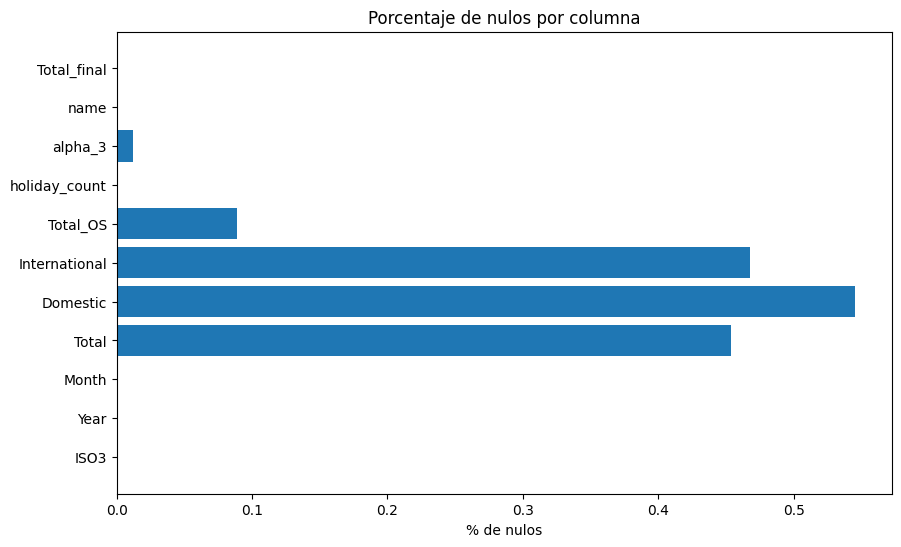

In [ ]:
import pandas as pd

# Cargar el archivo limpio
df = pd.read_excel("datarush_limpio.xlsx")

# 1. Conteo de nulos por columna
nulls = df.isna().sum().reset_index()
nulls.columns = ["columna", "nulos"]
nulls["%_nulos"] = (nulls["nulos"] / len(df)).round(3)
print(nulls)

# 2. Visualización rápida
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(nulls["columna"], nulls["%_nulos"])
plt.title("Porcentaje de nulos por columna")
plt.xlabel("% de nulos")
plt.show()


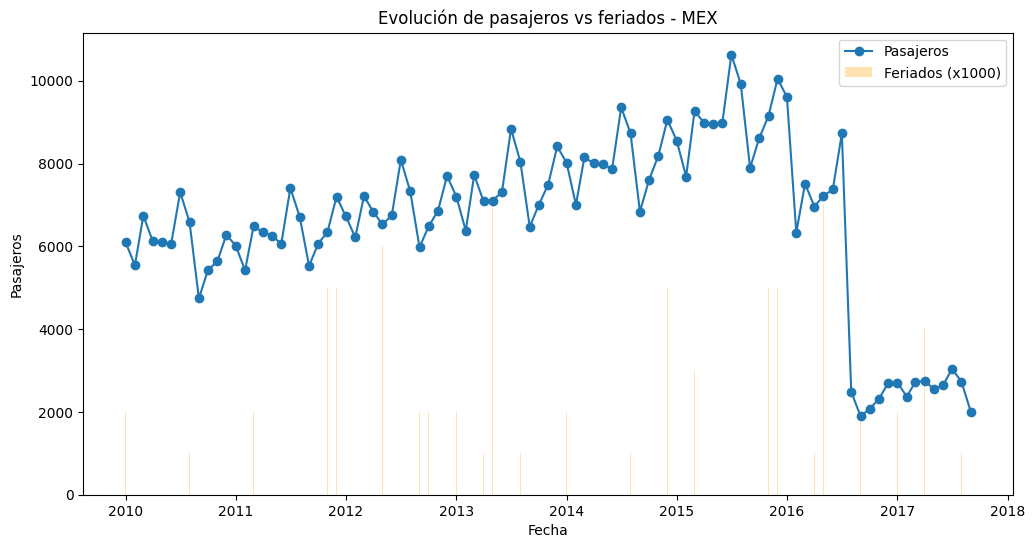

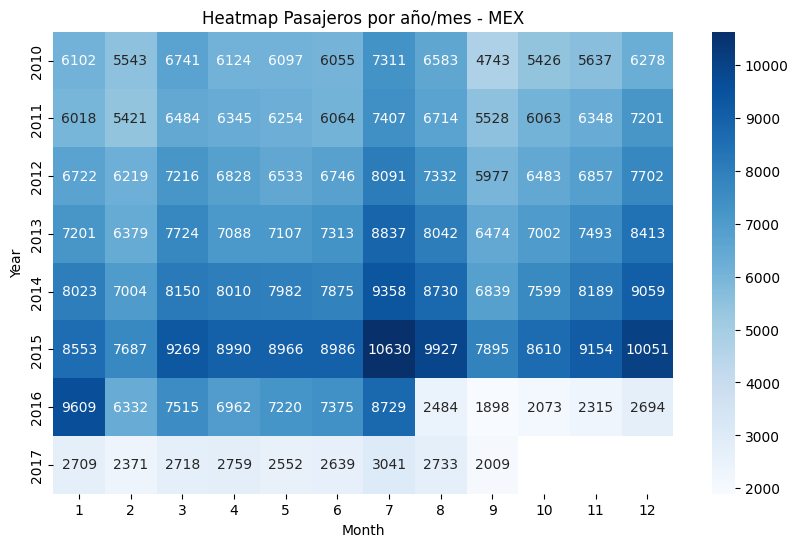

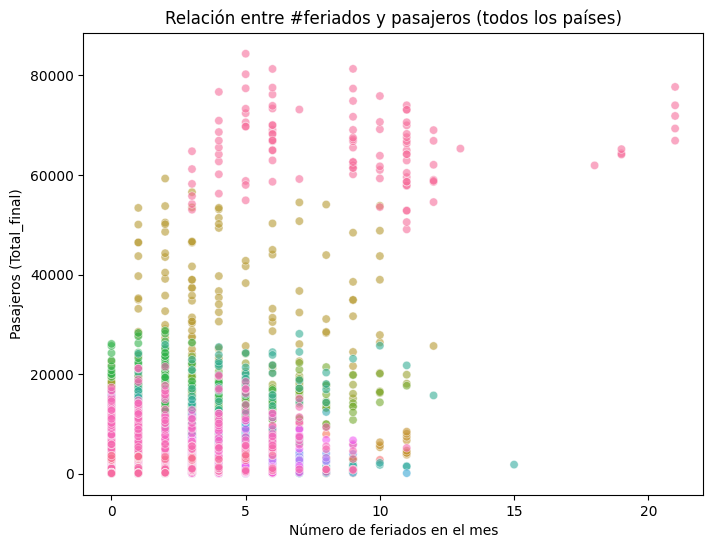


Top 10 países con mayor correlación (feriados vs pasajeros):
    ISO3  Total_final
38   CYM     0.407925
92   JAM     0.405623
52   EGY     0.366666
134  NZL     0.346230
24   BRB     0.285739
74   GTM     0.280711
168  TUR     0.279094
102  LCA     0.270607
142  PHL     0.172978
112  MAR     0.167930


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1) Cargar dataset limpio
# ==============================
df = pd.read_excel("datarush_limpio.xlsx")

# ==============================
# 2) Gráfico de línea por país (ejemplo MEX)
# ==============================
country = "MEX"  # cambia por ISO3 de interés
df_country = df[df["ISO3"] == country].copy()
df_country["date"] = pd.to_datetime(dict(year=df_country["Year"], month=df_country["Month"], day=1))

plt.figure(figsize=(12,6))
plt.plot(df_country["date"], df_country["Total_final"], marker="o", label="Pasajeros")
plt.bar(df_country["date"], df_country["holiday_count"]*1000, alpha=0.3, label="Feriados (x1000)", color="orange")
plt.title(f"Evolución de pasajeros vs feriados - {country}")
plt.xlabel("Fecha")
plt.ylabel("Pasajeros")
plt.legend()
plt.show()

# ==============================
# 3) Heatmap Año vs Mes (ejemplo MEX)
# ==============================
pivot = df_country.pivot_table(index="Year", columns="Month", values="Total_final", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title(f"Heatmap Pasajeros por año/mes - {country}")
plt.show()

# ==============================
# 4) Scatter holidays vs pasajeros
# ==============================
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="holiday_count", y="Total_final", hue="ISO3", alpha=0.6, legend=False)
plt.title("Relación entre #feriados y pasajeros (todos los países)")
plt.xlabel("Número de feriados en el mes")
plt.ylabel("Pasajeros (Total_final)")
plt.show()

# ==============================
# 5) Correlación por país
# ==============================
corrs = df.groupby("ISO3")[["holiday_count","Total_final"]].corr().reset_index()
corrs = corrs[corrs["level_1"]=="holiday_count"][["ISO3","Total_final"]].sort_values("Total_final", ascending=False)

print("\nTop 10 países con mayor correlación (feriados vs pasajeros):")
print(corrs.head(10))


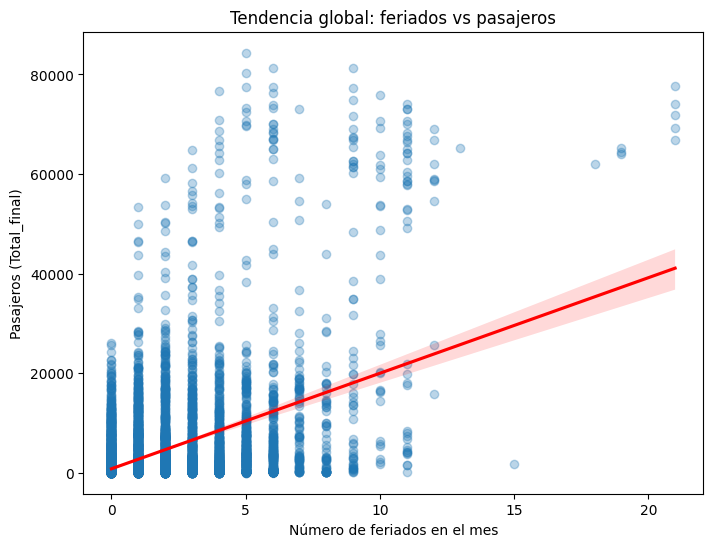

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(data=df, x="holiday_count", y="Total_final",
            scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Tendencia global: feriados vs pasajeros")
plt.xlabel("Número de feriados en el mes")
plt.ylabel("Pasajeros (Total_final)")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Cargar
df = pd.read_excel("datarush_limpio.xlsx")
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Baseline estacional por país-mes y delta %
seasonal = df.groupby(["ISO3","Month"])["Total_final"].mean().rename("seasonal_expected")
df = df.merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_pct"] = (df["Total_final"] - df["seasonal_expected"]) / df["seasonal_expected"]


In [ ]:
def country_sensitivity(d):
    # correlación feriados vs delta_pct + pendiente (elasticidad aproximada)
    if d["holiday_count"].nunique() <= 1 or d["delta_pct"].isna().all():
        return pd.Series({"corr": np.nan, "pval": np.nan, "slope": np.nan, "n": len(d)})
    x = d["holiday_count"].astype(float)
    y = d["delta_pct"].astype(float)
    ok = x.notna() & y.notna()
    if ok.sum() < 6:
        return pd.Series({"corr": np.nan, "pval": np.nan, "slope": np.nan, "n": ok.sum()})
    r, p = stats.pearsonr(x[ok], y[ok])
    slope = np.polyfit(x[ok], y[ok], 1)[0]  # cambio en delta_pct por feriado extra
    return pd.Series({"corr": r, "pval": p, "slope": slope, "n": ok.sum()})

rank = df.groupby("ISO3").apply(country_sensitivity).reset_index()
rank = rank.sort_values("slope", ascending=False)

print("TOP positivos (más suben con feriados):")
display(rank.head(10))

print("\nTOP negativos (caen cuando hay más feriados):")
display(rank.sort_values("slope").head(10))

# Exporta para tu deck
rank.to_csv("ranking_sensibilidad_paises.csv", index=False)


TOP positivos (más suben con feriados):


/tmp/ipython-input-1709864102.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(x[ok], y[ok])
/tmp/ipython-input-1709864102.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank = df.groupby("ISO3").apply(country_sensitivity).reset_index()


,ISO3,corr,pval,slope,n
40,HUN,0.177342,0.066338,0.028052,108.0
57,MDA,0.102010,0.325275,0.017029,95.0
85,TWN,0.067468,0.648657,0.012459,48.0
75,ROU,0.081119,0.403952,0.012143,108.0
79,SRB,0.078471,0.447282,0.011185,96.0
34,GIB,0.059245,0.566389,0.010660,96.0
15,CHL,0.057124,0.687505,0.010504,52.0
81,SVN,0.059091,0.543535,0.009975,108.0
36,GRC,0.030382,0.754937,0.008797,108.0
74,PRY,0.075654,0.473528,0.008707,92.0



TOP negativos (caen cuando hay más feriados):


,ISO3,corr,pval,slope,n
70,PER,-0.117632,0.253693,-0.034434,96.0
7,BGR,-0.026177,0.787995,-0.004035,108.0
56,MAR,-0.073237,0.578140,-0.003504,60.0
10,BLR,-0.011380,0.956944,-0.002940,25.0
84,TUR,-0.020848,0.840216,-0.002739,96.0
71,PHL,-0.046917,0.751505,-0.002187,48.0
77,SGP,-0.056157,0.704608,-0.002052,48.0
28,EST,-0.009455,0.922636,-0.001869,108.0
69,PAN,-0.004262,0.967128,-0.000843,96.0
80,SVK,-0.005566,0.954406,-0.000817,108.0


                count     mean      50%     min      max
holiday_count                                           
0              1794.0   2573.5    977.9    12.8  26089.3
1              1932.0   3074.4    929.2    15.5  53409.0
2              1255.0   3816.0   1203.3    18.8  59304.0
3               764.0   5115.1   1488.8    26.0  64786.0
4               571.0   5656.0   1678.7    16.4  76706.0
5               382.0   7553.5   3810.2    20.0  84373.0
6               246.0  10409.9   3725.3    55.2  81318.0
7                91.0  11880.4   7789.5    95.3  73165.0
8                61.0   9060.1   4099.0   102.0  54084.0
9                54.0  27263.7  15608.3   129.0  81334.0
10               27.0  33654.5  26377.0  1779.2  75880.0
11               40.0  39545.7  52867.0   124.7  74018.0
12               20.0  57655.0  64237.0  1843.8  77706.0


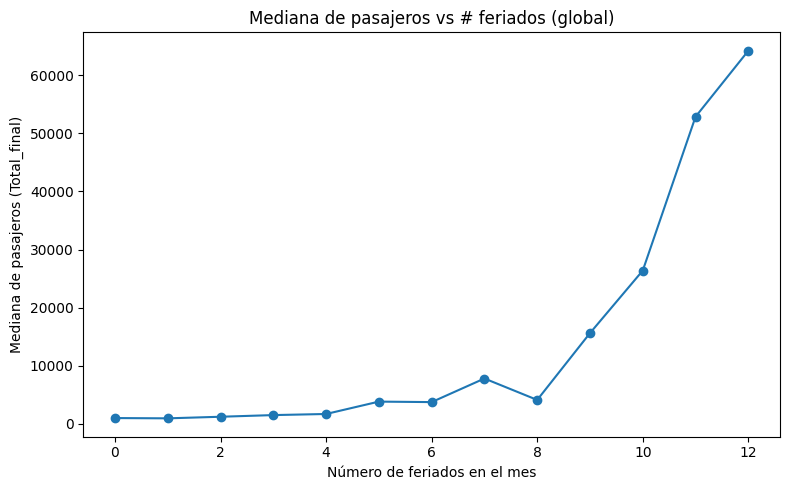

In [ ]:
agg = (df.assign(holiday_count=df["holiday_count"].clip(upper=12))  # recorta outliers largos
         .groupby("holiday_count")["Total_final"].describe())

print(agg[["count","mean","50%","min","max"]].round(1))

# Gráfico (matplotlib, simple)
x = agg.index.values
y = agg["50%"].values  # mediana
plt.figure(figsize=(8,5))
plt.plot(x, y, marker='o')
plt.xlabel("Número de feriados en el mes")
plt.ylabel("Mediana de pasajeros (Total_final)")
plt.title("Mediana de pasajeros vs # feriados (global)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2340250404.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby("holiday_bin")["Total_final"].mean().reindex(labels)


holiday_bin
0       2574.0
1-3     3705.0
4-6     7236.0
7-9    15078.0
10+    41880.0
Name: Total_final, dtype: float64


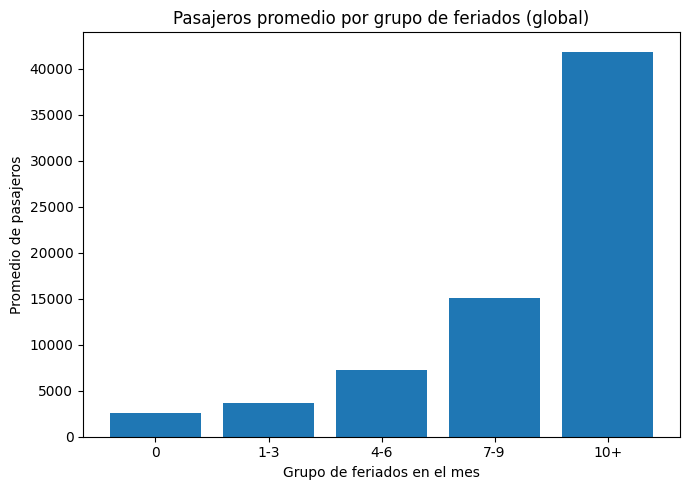

In [ ]:
bins = [-1,0,3,6,9,99]
labels = ["0","1-3","4-6","7-9","10+"]
df["holiday_bin"] = pd.cut(df["holiday_count"], bins=bins, labels=labels)

grp = df.groupby("holiday_bin")["Total_final"].mean().reindex(labels)
print(grp.round(0))

plt.figure(figsize=(7,5))
plt.bar(grp.index.astype(str), grp.values)
plt.xlabel("Grupo de feriados en el mes")
plt.ylabel("Promedio de pasajeros")
plt.title("Pasajeros promedio por grupo de feriados (global)")
plt.tight_layout()
plt.show()


     mean
tm1  0.25
t0   0.89
tp1  1.04


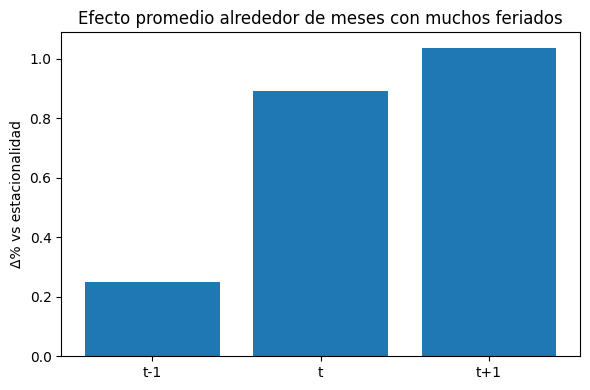

In [ ]:
# Umbral alto por país (percentil 75)
p75 = df.groupby("ISO3")["holiday_count"].transform(lambda s: s.quantile(0.75))
df["high_holiday"] = (df["holiday_count"] >= p75).astype(int)

# Construir t-1, t, t+1
df = df.sort_values(["ISO3","date"])
df["delta_pct_lag1"] = df.groupby("ISO3")["delta_pct"].shift(1)
df["delta_pct_lead1"] = df.groupby("ISO3")["delta_pct"].shift(-1)

event_tbl = (df[df["high_holiday"]==1]
             .assign(tm1=lambda x: x["delta_pct_lag1"],
                     t0=lambda x: x["delta_pct"],
                     tp1=lambda x: x["delta_pct_lead1"])
             [["ISO3","tm1","t0","tp1"]])

event_mean = event_tbl[["tm1","t0","tp1"]].mean().rename("mean").to_frame()
print((event_mean*100).round(2))  # en %

plt.figure(figsize=(6,4))
plt.bar(["t-1","t","t+1"], (event_mean["mean"]*100).values)
plt.ylabel("Δ% vs estacionalidad")
plt.title("Efecto promedio alrededor de meses con muchos feriados")
plt.tight_layout()
plt.show()


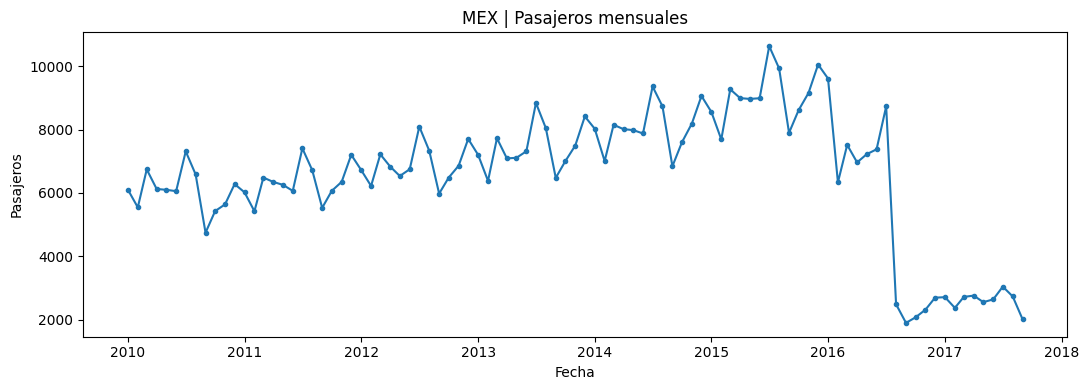

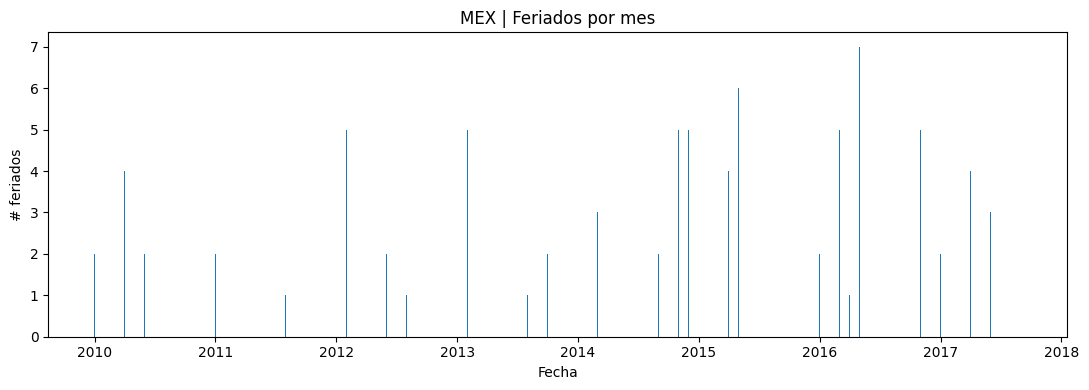

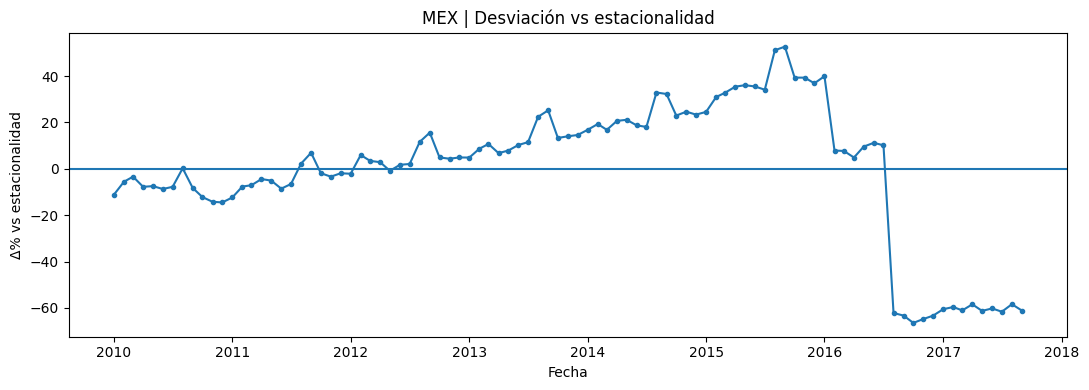

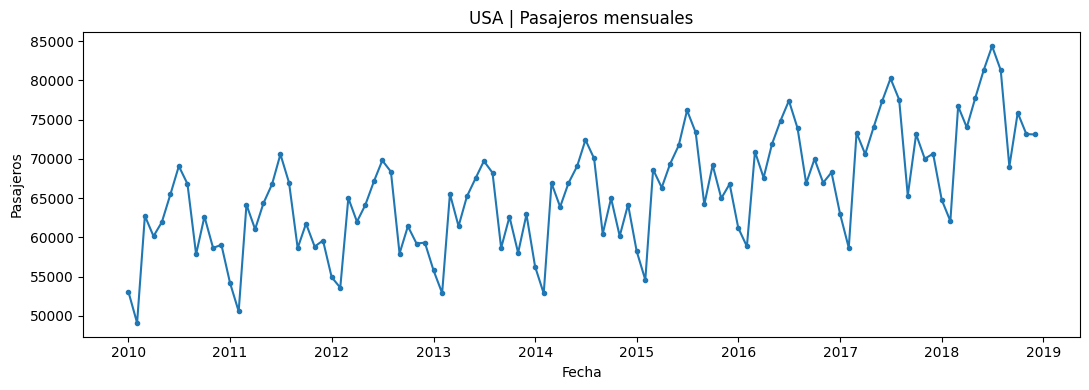

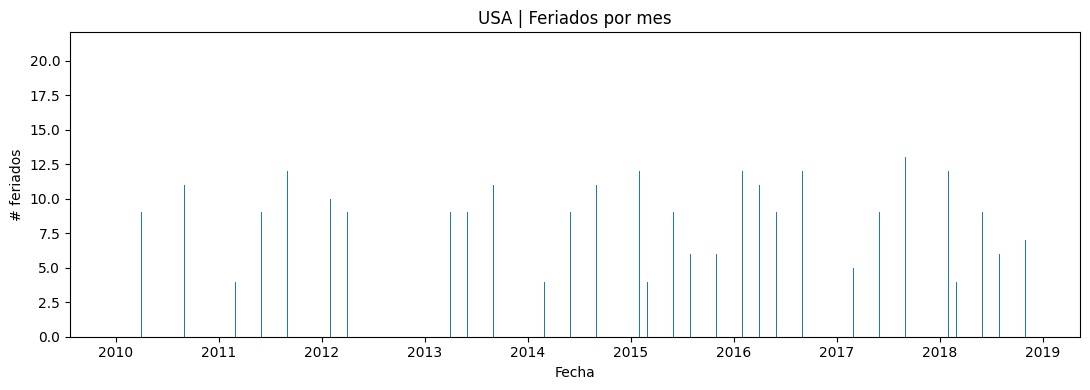

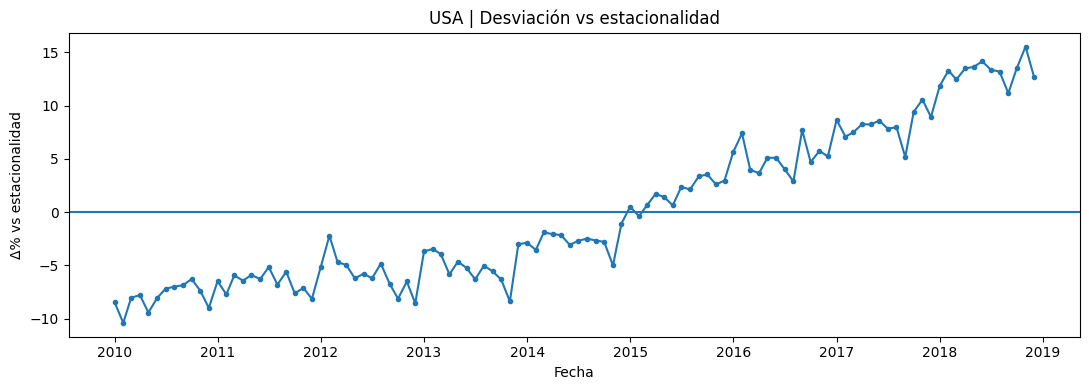

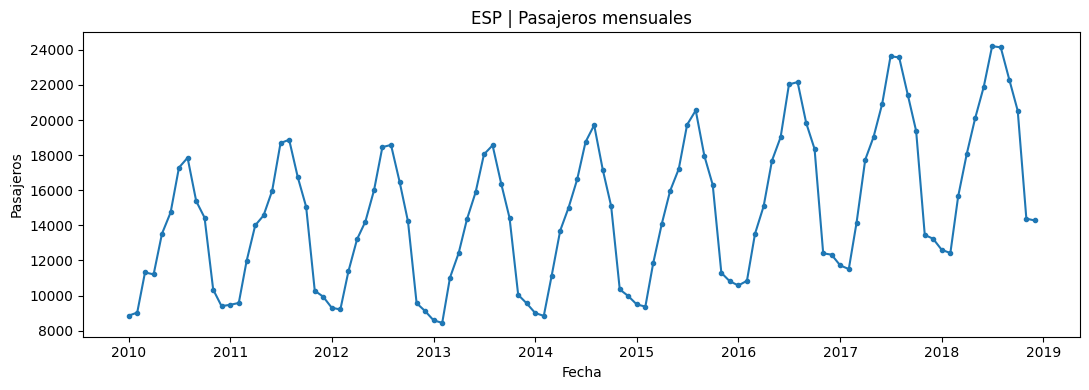

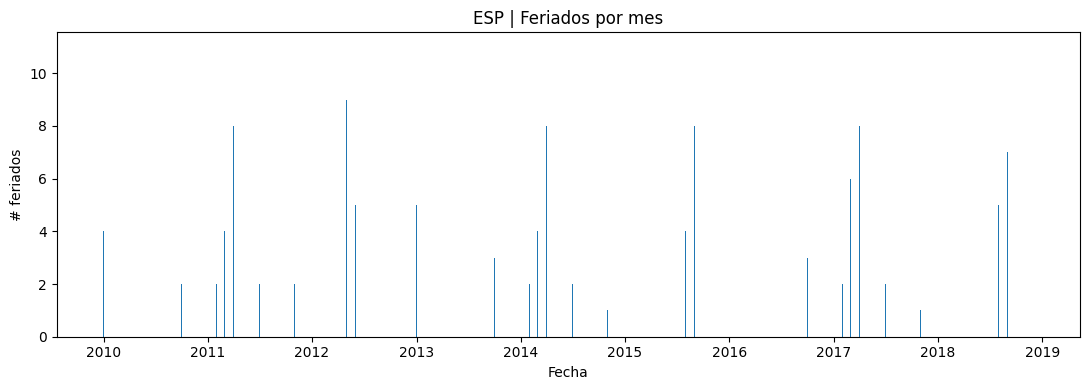

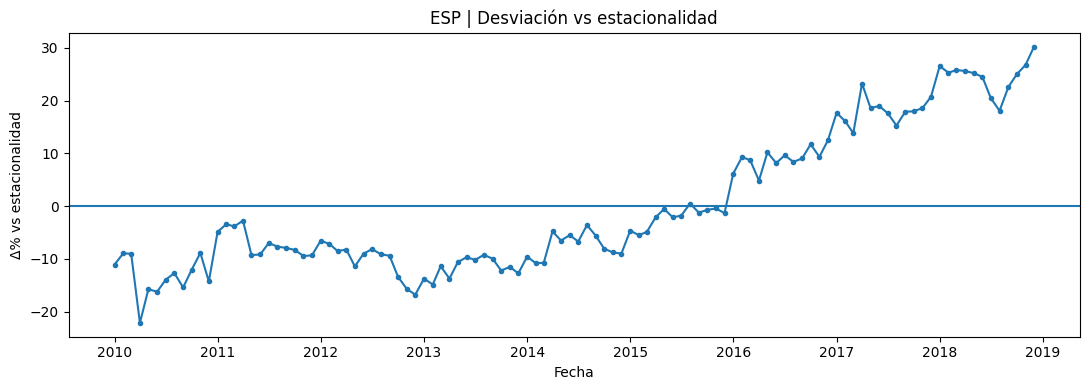

In [ ]:
def country_panel(iso):
    d = df[df["ISO3"]==iso].copy()
    d = d.sort_values("date")
    plt.figure(figsize=(11,4))
    plt.plot(d["date"], d["Total_final"], marker='.')
    plt.xlabel("Fecha"); plt.ylabel("Pasajeros")
    plt.title(f"{iso} | Pasajeros mensuales")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(11,4))
    plt.bar(d["date"], d["holiday_count"])
    plt.xlabel("Fecha"); plt.ylabel("# feriados")
    plt.title(f"{iso} | Feriados por mes")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(11,4))
    plt.plot(d["date"], d["delta_pct"]*100, marker='.')
    plt.axhline(0)
    plt.xlabel("Fecha"); plt.ylabel("Δ% vs estacionalidad")
    plt.title(f"{iso} | Desviación vs estacionalidad")
    plt.tight_layout(); plt.show()

for iso in ["MEX","USA","ESP"]:  # cambia la lista a tus países objetivo
    country_panel(iso)


In [ ]:
recs = pd.DataFrame([
    # Ejemplos; rellena con tus hallazgos
    {"Sector":"Aerolíneas","País":"MEX","Idea":"Aumentar capacidad en t0 (mes de feriados altos) y mantener +1 semana",
     "KPI":"Load factor","Cómo medir":"Δp.p. vs promedio Q2-Q4","Impacto":"Alto","Esfuerzo":"Medio","Prioridad":1},
    {"Sector":"Hospitality","País":"ESP","Idea":"Tarifa estacional + staffing extra en fines largos",
     "KPI":"RevPAR","Cómo medir":"Δ% vs mismo mes años previos","Impacto":"Medio","Esfuerzo":"Bajo","Prioridad":2},
    {"Sector":"Retail","País":"USA","Idea":"Promos en aeropuerto t-1 y t+1 (rebote post-feriado)",
     "KPI":"Ticket promedio","Cómo medir":"Δ% vs baseline semanal","Impacto":"Medio","Esfuerzo":"Medio","Prioridad":3},
])
recs.to_csv("tabla_recomendaciones.csv", index=False)
recs


,Sector,País,Idea,KPI,Cómo medir,Impacto,Esfuerzo,Prioridad
0,Aerolíneas,MEX,Aumentar capacidad en t0 (mes de feriados alto...,Load factor,Δp.p. vs promedio Q2-Q4,Alto,Medio,1
1,Hospitality,ESP,Tarifa estacional + staffing extra en fines la...,RevPAR,Δ% vs mismo mes años previos,Medio,Bajo,2
2,Retail,USA,Promos en aeropuerto t-1 y t+1 (rebote post-fe...,Ticket promedio,Δ% vs baseline semanal,Medio,Medio,3


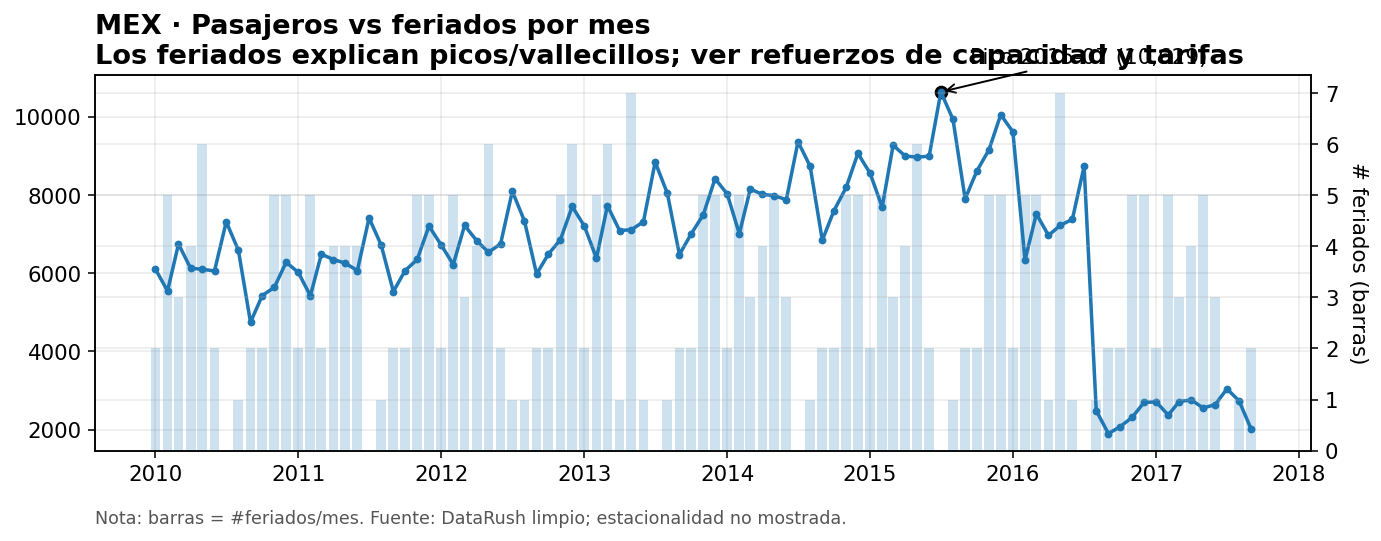

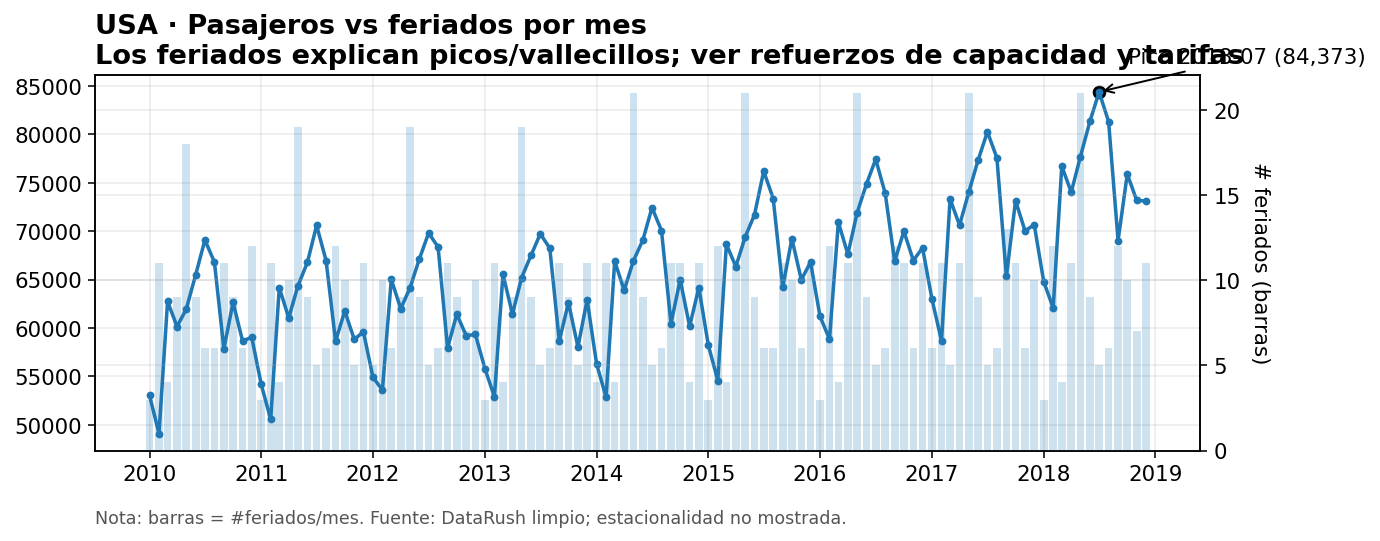

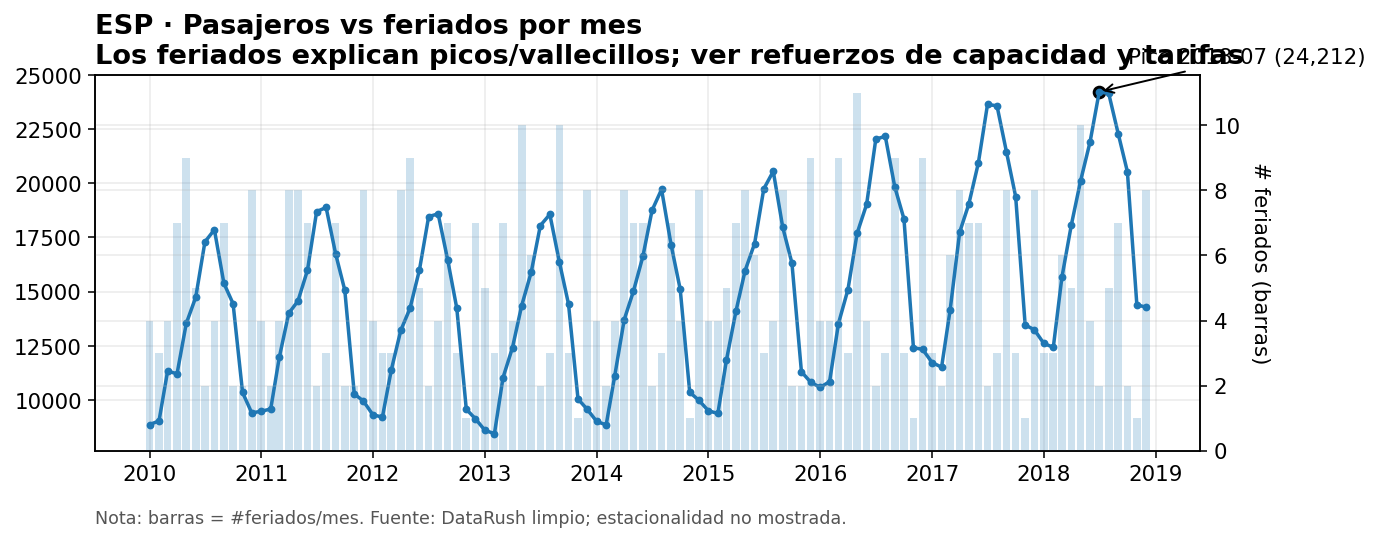

/tmp/ipython-input-431565550.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = tmp.groupby("holiday_bin")["Total_final"].mean().reindex(labels)


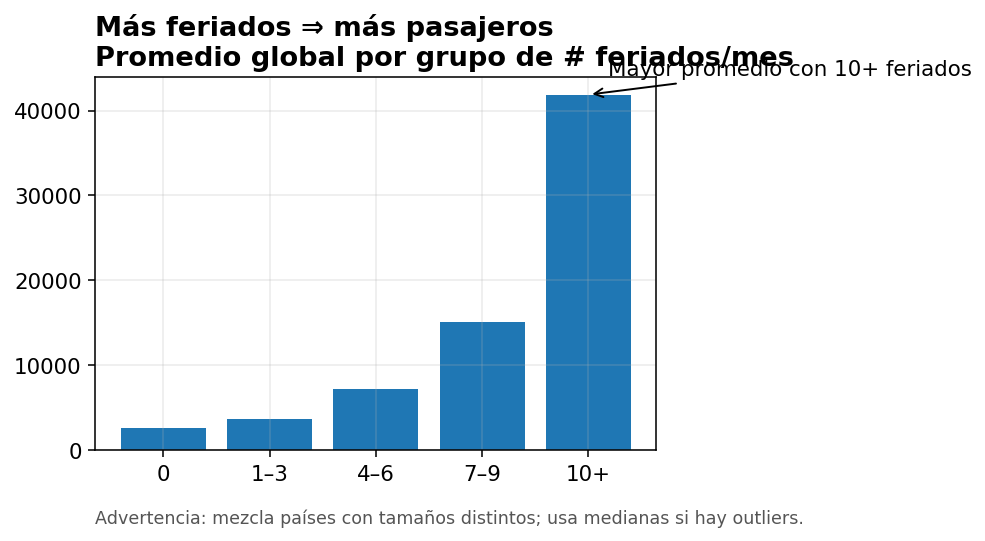

/tmp/ipython-input-431565550.py:104: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slopes = d.groupby("ISO3").apply(country_sensitivity).dropna().sort_values(ascending=False)


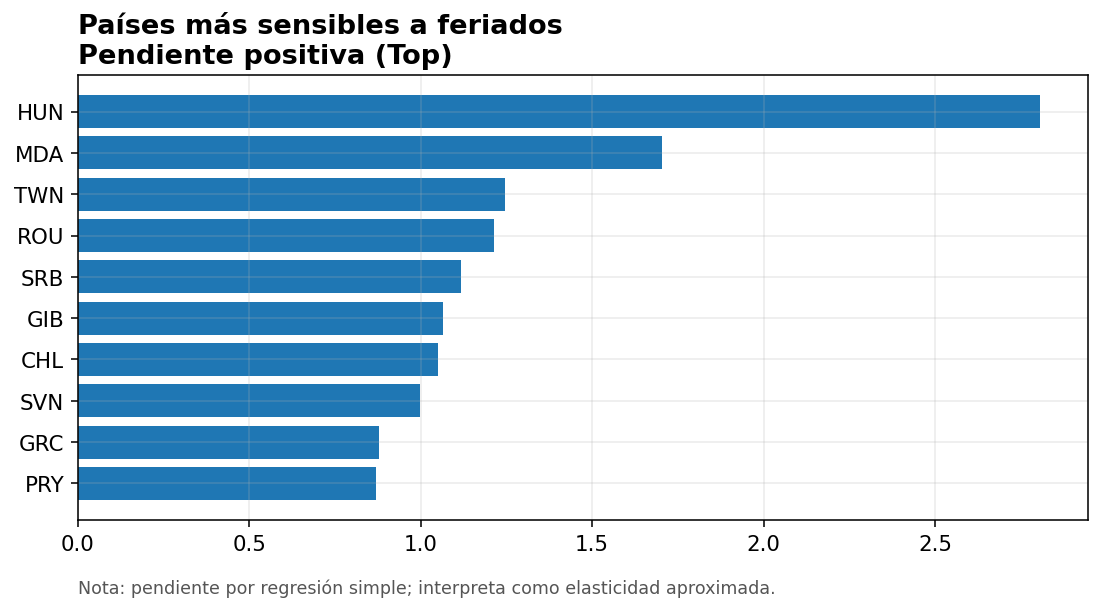

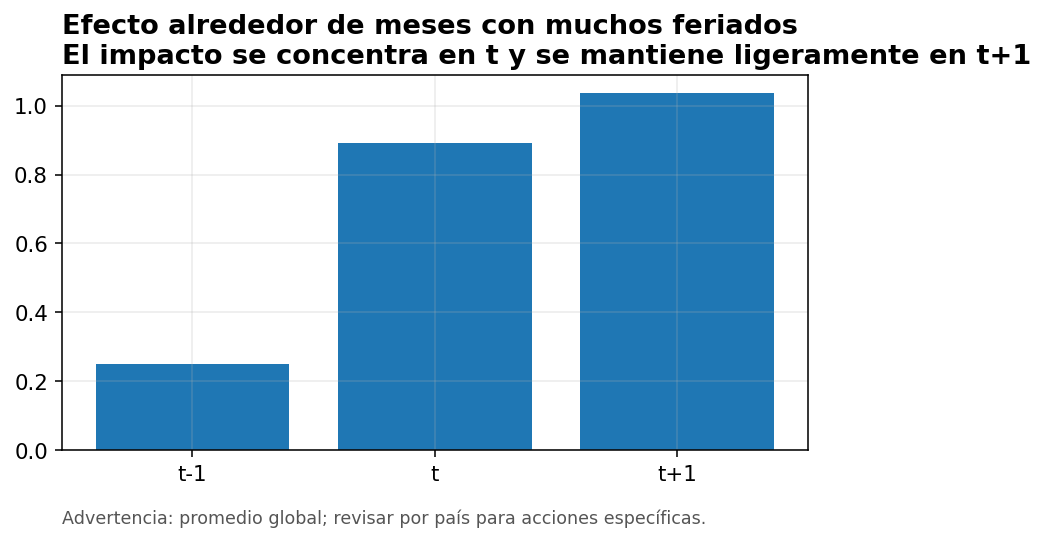

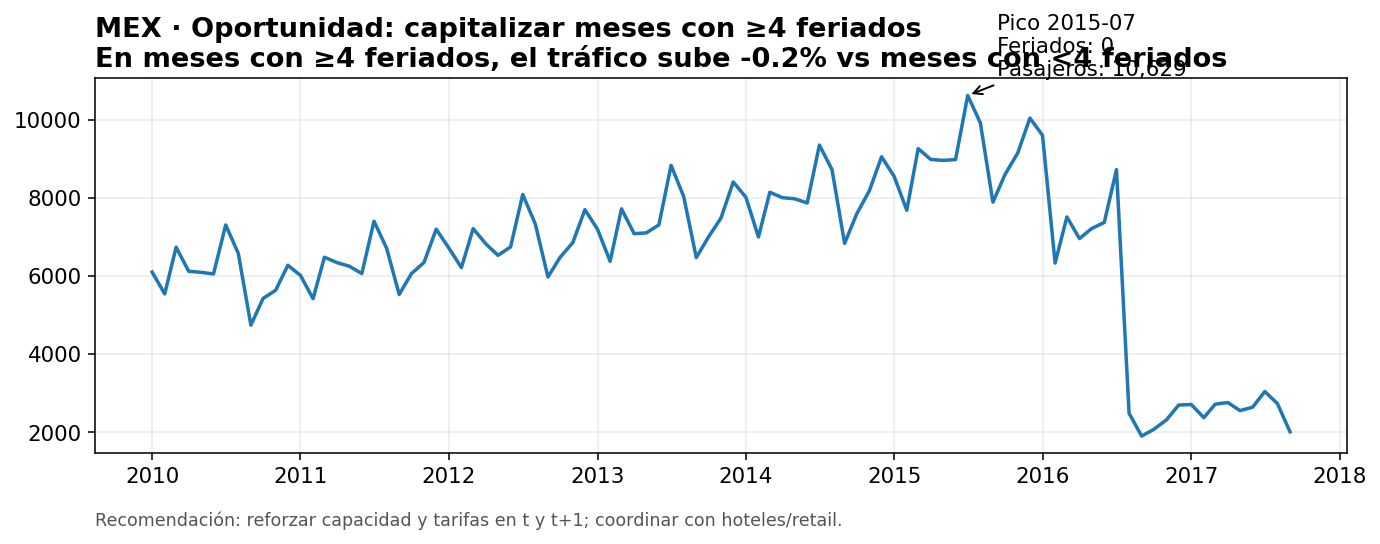

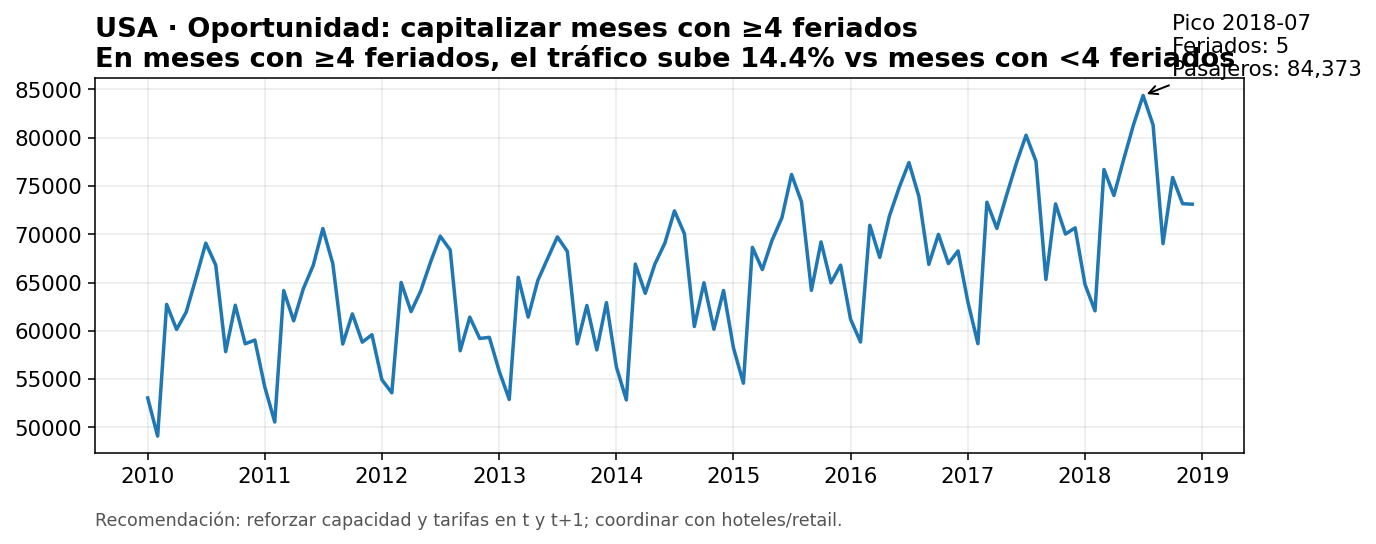

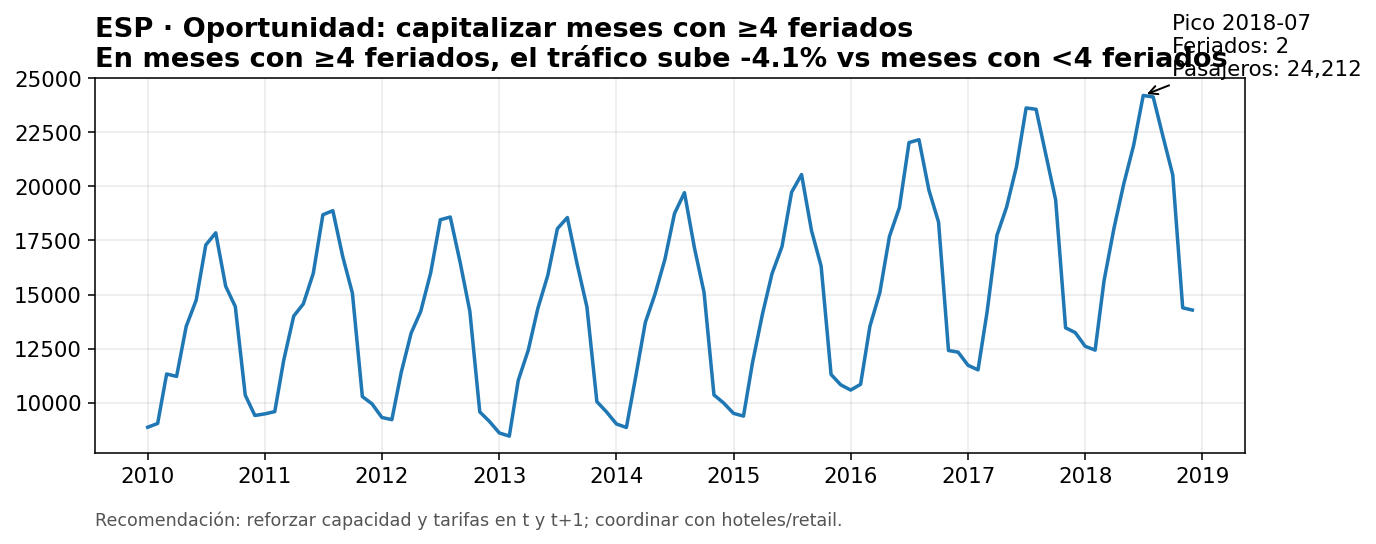

Listo. Revisa la carpeta: /content/export_figs


In [ ]:
# =========================================
# DataRush - Storytelling Visual Pack (Matplotlib)
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- Estilo básico (sobrio y ejecutivo)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

OUT = Path("export_figs"); OUT.mkdir(exist_ok=True)

# ---------- Carga
df = pd.read_excel("datarush_limpio.xlsx")
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Baseline estacional y delta %
seasonal = df.groupby(["ISO3","Month"])["Total_final"].mean().rename("seasonal_expected")
df = df.merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_pct"] = (df["Total_final"] - df["seasonal_expected"]) / df["seasonal_expected"]

# Helpers de formato
def pct(x):
    return f"{x*100:.1f}%"

def footnote(ax, text):
    ax.annotate(text, (0,0), (0, -30), xycoords='axes fraction', textcoords='offset points', va='top', fontsize=9, color="#555")

def headline(ax, title, subtitle):
    ax.set_title(title + "\n" + subtitle, loc="left", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")

# ==========================================================
# V1. Línea con barras (pasajeros vs feriados) + insight/nota
# ==========================================================
def fig_country_timeline(d, iso="MEX"):
    t = d[d.ISO3==iso].sort_values("date").copy()
    if t.empty:
        print(f"[WARN] No data for {iso}");
        return
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(t["date"], t["Total_final"], marker=".", lw=1.8)
    ax2 = ax.twinx()
    ax2.bar(t["date"], t["holiday_count"], width=25, alpha=0.22)
    ax.set_ylabel("Pasajeros (Total_final)")
    ax2.set_ylabel("# feriados (barras)", rotation=270, labelpad=15)
    title = f"{iso} · Pasajeros vs feriados por mes"
    subtitle = "Los feriados explican picos/vallecillos; ver refuerzos de capacidad y tarifas"
    headline(ax, title, subtitle)
    # Insight simple: mes pico
    row = t.loc[t.Total_final.idxmax()]
    ax.scatter([row["date"]],[row["Total_final"]], color="black")
    ax.annotate(f"Pico {row['date'].strftime('%Y-%m')} ({int(row['Total_final']):,})",
                xy=(row["date"], row["Total_final"]), xytext=(15,15),
                textcoords="offset points", arrowprops=dict(arrowstyle="->", lw=1))
    footnote(ax, "Nota: barras = #feriados/mes. Fuente: DataRush limpio; estacionalidad no mostrada.")
    plt.tight_layout()
    plt.savefig(OUT/f"V1_timeline_{iso}.png", bbox_inches="tight")
    plt.show()

# ==========================================================
# V2. Barras por grupos de feriados (promedio pasajeros)
# ==========================================================
def fig_bins_global(d):
    bins = [-1,0,3,6,9,99]; labels = ["0","1–3","4–6","7–9","10+"]
    tmp = d.copy()
    tmp["holiday_bin"] = pd.cut(tmp["holiday_count"], bins=bins, labels=labels)
    g = tmp.groupby("holiday_bin")["Total_final"].mean().reindex(labels)
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(g.index.astype(str), g.values)
    ax.set_ylabel("Pasajeros promedio")
    headline(ax, "Más feriados ⇒ más pasajeros",
             "Promedio global por grupo de # feriados/mes")
    # Insight (marcar top)
    top_lab = g.idxmax()
    ax.annotate(f"Mayor promedio con {top_lab} feriados",
                xy=(list(g.index).index(top_lab), g.max()),
                xytext=(10,10), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", lw=1))
    footnote(ax, "Advertencia: mezcla países con tamaños distintos; usa medianas si hay outliers.")
    plt.tight_layout()
    plt.savefig(OUT/"V2_bins_global.png", bbox_inches="tight")
    plt.show()

# ==========================================================
# V3. Ranking “sensibilidad a feriados” (pendiente por país)
# ==========================================================
def country_sensitivity(d):
    x = d["holiday_count"].astype(float)
    y = d["delta_pct"].astype(float)
    m = x.notna() & y.notna()
    x, y = x[m], y[m]
    if len(x) < 12 or x.nunique()<2 or y.nunique()<2:
        return np.nan
    return np.polyfit(x, y, 1)[0]  # Δ% vs estacionalidad por feriado extra

def fig_top_sensitivity(d, k=10):
    slopes = d.groupby("ISO3").apply(country_sensitivity).dropna().sort_values(ascending=False)
    top = slopes.head(k).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8,4.5))
    ax.barh(top.index, top.values*100)
    ax.set_xlabel("Cambio en Δ% vs estacionalidad por feriado extra (p.p.)")
    headline(ax, "Países más sensibles a feriados", "Pendiente positiva (Top)")
    footnote(ax, "Nota: pendiente por regresión simple; interpreta como elasticidad aproximada.")
    plt.tight_layout()
    plt.savefig(OUT/"V3_top_sensitivity.png", bbox_inches="tight")
    plt.show()
    # También guardamos CSV
    slopes.rename("slope").to_csv(OUT/"ranking_sensibilidad.csv")

# ==========================================================
# V4. Event-study (t-1, t, t+1) alrededor de meses con muchos feriados
# ==========================================================
def fig_event_study(d):
    p75 = d.groupby("ISO3")["holiday_count"].transform(lambda s: s.quantile(0.75))
    x = d.assign(high=(d["holiday_count"]>=p75).astype(int)).sort_values(["ISO3","date"])
    x["tm1"] = x.groupby("ISO3")["delta_pct"].shift(1)
    x["t0"]  = x["delta_pct"]
    x["tp1"] = x.groupby("ISO3")["delta_pct"].shift(-1)
    ev = x[x["high"]==1][["tm1","t0","tp1"]].mean()*100
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(["t-1","t","t+1"], [ev["tm1"], ev["t0"], ev["tp1"]])
    ax.set_ylabel("Δ% vs estacionalidad (promedio global)")
    headline(ax, "Efecto alrededor de meses con muchos feriados",
             "El impacto se concentra en t y se mantiene ligeramente en t+1")
    footnote(ax, "Advertencia: promedio global; revisar por país para acciones específicas.")
    plt.tight_layout()
    plt.savefig(OUT/"V4_event_study.png", bbox_inches="tight")
    plt.show()

# ==========================================================
# V5. KPI slide (una lámina rápida por país)
# ==========================================================
def fig_kpi_country(d, iso="MEX"):
    t = d[d.ISO3==iso].copy()
    if t.empty:
        print(f"[WARN] No data for {iso}");
        return
    # KPI 1: Δ% promedio en meses con 4+ feriados vs el resto
    t["is_high"] = (t["holiday_count"]>=4).astype(int)
    kpi = t.groupby("is_high")["Total_final"].mean()
    uplift = (kpi.get(1, np.nan) - kpi.get(0, np.nan)) / kpi.get(0, np.nan)
    # KPI 2: mes pico y feriados de ese mes
    row = t.sort_values("Total_final").tail(1).iloc[0]
    # Gráfico mini
    t = t.sort_values("date")
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(t["date"], t["Total_final"], lw=1.8)
    ax.set_ylabel("Pasajeros")
    title = f"{iso} · Oportunidad: capitalizar meses con ≥4 feriados"
    sub = f"En meses con ≥4 feriados, el tráfico sube {pct(uplift) if pd.notna(uplift) else 'N/A'} vs meses con <4 feriados"
    headline(ax, title, sub)
    ax.annotate(f"Pico {row['Year']}-{int(row['Month']):02d}\nFeriados: {int(row['holiday_count'])}\nPasajeros: {int(row['Total_final']):,}",
                xy=(row["date"], row["Total_final"]), xytext=(15,10),
                textcoords="offset points", arrowprops=dict(arrowstyle='->', lw=1))
    footnote(ax, "Recomendación: reforzar capacidad y tarifas en t y t+1; coordinar con hoteles/retail.")
    plt.tight_layout()
    plt.savefig(OUT/f"V5_kpi_{iso}.png", bbox_inches="tight")
    plt.show()

# --------- Ejecutar ejemplos
countries = ["MEX","USA","ESP"]  # ← cambia tu lista objetivo
for c in countries:
    fig_country_timeline(df, c)
fig_bins_global(df)
fig_top_sensitivity(df, k=10)
fig_event_study(df)
for c in countries:
    fig_kpi_country(df, c)

print("Listo. Revisa la carpeta:", OUT.resolve())


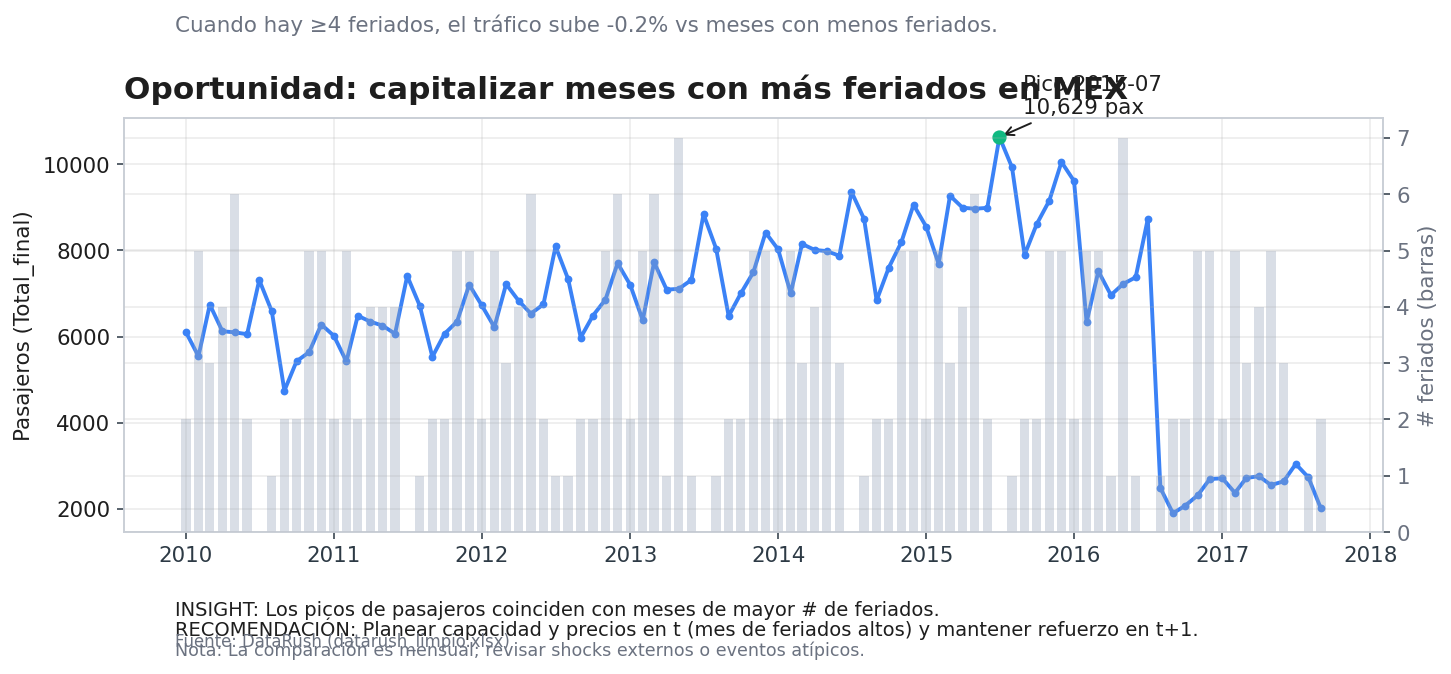

/tmp/ipython-input-48810693.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = x.groupby("holiday_bin")["Total_final"].mean().reindex(labels)


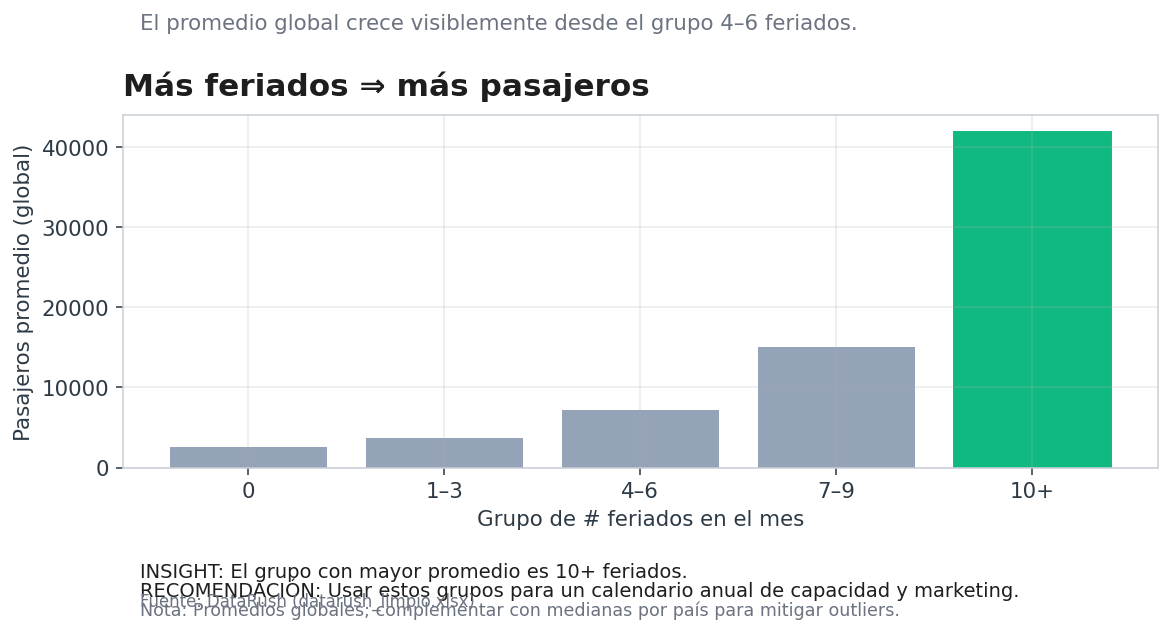

/tmp/ipython-input-48810693.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = d.groupby("ISO3").apply(slope_sensitivity).dropna().sort_values(ascending=False)


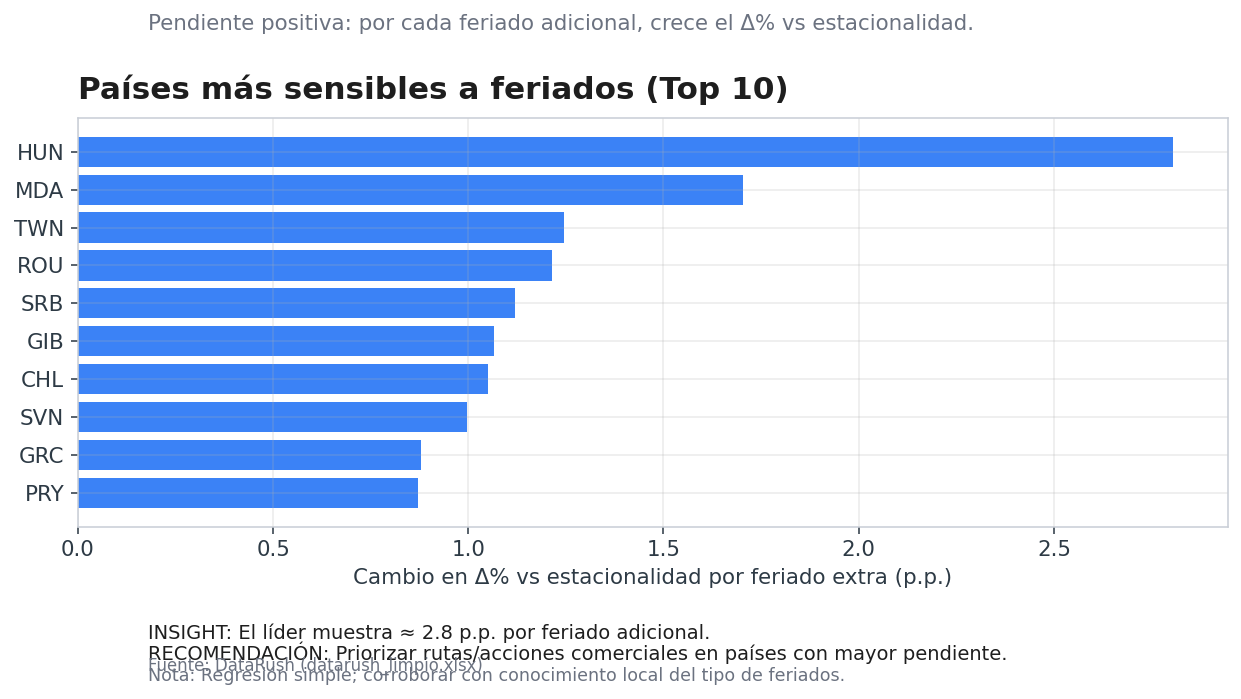

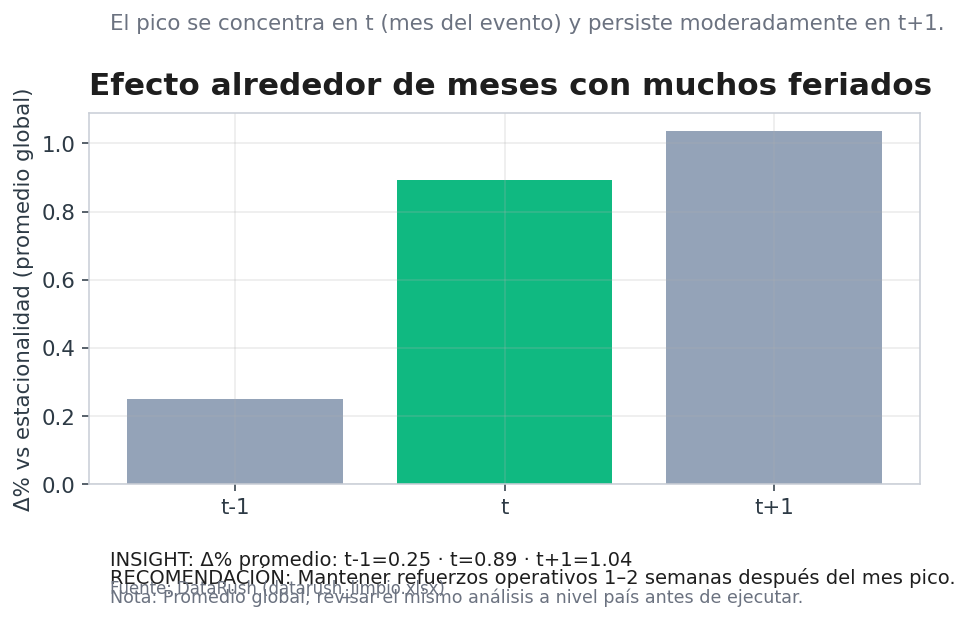

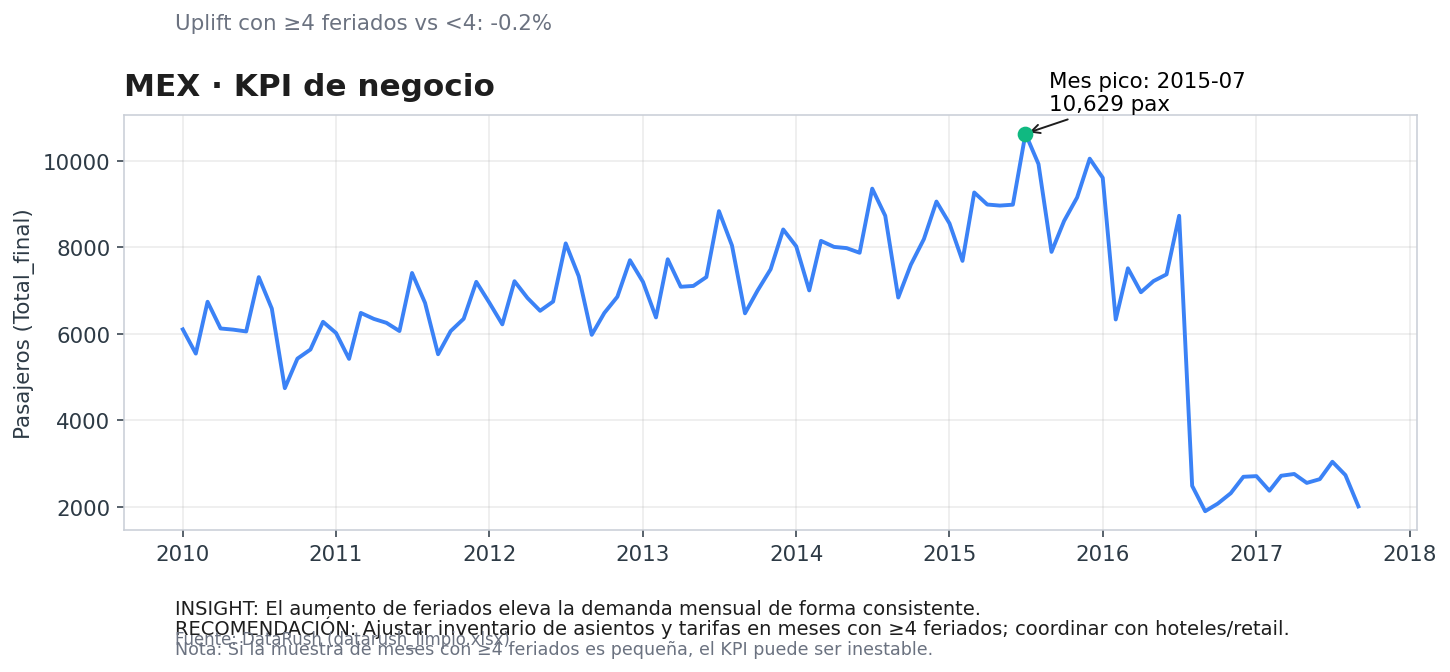

Listo ✅  Revisa la carpeta: /content/export_figs


In [ ]:
# ================================================
# DataRush · Visual Pack Ejecutivo (Matplotlib)
# ================================================
# Requisitos: pandas, numpy, matplotlib (vienen en Colab por defecto)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# -------- Configuración general (look & feel)
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.edgecolor": "#C9CED6",
    "axes.labelcolor": "#2D3A45",
    "xtick.color": "#2D3A45",
    "ytick.color": "#2D3A45",
})

# Paleta (inspirada en tu referencia): grises, azules y acento teal
COL_TEXT     = "#1E1E1E"
COL_SUBTEXT  = "#6B7280"  # gris
COL_LINE     = "#3B82F6"  # azul
COL_BAR      = "#94A3B8"  # gris azulado
COL_ACCENT   = "#10B981"  # teal/verde para KPIs
COL_WARN     = "#EF4444"  # rojo suave para advertencias

OUT = Path("export_figs"); OUT.mkdir(exist_ok=True)

# -------- Carga de datos
df = pd.read_excel("datarush_limpio.xlsx")  # columnas mínimas: ISO3, Year, Month, holiday_count, Total_final, name
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# -------- Baseline estacional y delta %
seasonal = df.groupby(["ISO3","Month"])["Total_final"].mean().rename("seasonal_expected")
df = df.merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_pct"] = (df["Total_final"] - df["seasonal_expected"]) / df["seasonal_expected"]

# -------- Utilidades
def pct(x):
    try:    return f"{x*100:.1f}%"
    except: return "N/A"

def add_titles(fig, ax, titulo, subtitulo):
    ax.set_title(titulo, loc="left", fontsize=16, color=COL_TEXT, pad=10)
    fig.text(0.125, 0.93, subtitulo, fontsize=11, color=COL_SUBTEXT)  # arriba, bajo el título

def add_footer(fig, insight=None, recomendacion=None, nota=None):
    y = 0.06
    if insight:
        fig.text(0.125, y, f"INSIGHT: {insight}", fontsize=10, color=COL_TEXT); y -= 0.03
    if recomendacion:
        fig.text(0.125, y, f"RECOMENDACIÓN: {recomendacion}", fontsize=10, color=COL_TEXT); y -= 0.03
    if nota:
        fig.text(0.125, y, f"Nota: {nota}", fontsize=9, color=COL_SUBTEXT)
    fig.text(0.125, 0.015, "Fuente: DataRush (datarush_limpio.xlsx)", fontsize=8.5, color=COL_SUBTEXT)

def savefig(fig, path):
    fig.tight_layout(rect=[0,0.1,1,0.9])  # deja espacio arriba/abajo para textos
    fig.savefig(path, bbox_inches="tight")
    plt.show()

# -------- KPIs base: uplift con ≥4 feriados
def compute_uplift_country(d, iso="MEX", thr=4):
    t = d[d.ISO3==iso].copy()
    if t.empty: return np.nan
    a = t.loc[t["holiday_count"] >= thr, "Total_final"].mean()
    b = t.loc[t["holiday_count"] <  thr, "Total_final"].mean()
    if pd.isna(a) or pd.isna(b) or b==0: return np.nan
    return (a/b) - 1.0

# -------- Sensibilidad a feriados (pendiente de delta_pct ~ holiday_count)
def slope_sensitivity(group):
    x = group["holiday_count"].astype(float)
    y = group["delta_pct"].astype(float)
    m = x.notna() & y.notna()
    x, y = x[m], y[m]
    if len(x) < 12 or x.nunique()<2 or y.nunique()<2:
        return np.nan
    return np.polyfit(x, y, 1)[0]  # cambio en Δ% por feriado extra

def ranking_sensibilidad(d):
    r = d.groupby("ISO3").apply(slope_sensitivity).dropna().sort_values(ascending=False)
    out = r.rename("slope").reset_index()
    out.to_csv(OUT/"ranking_sensibilidad.csv", index=False)
    return out

# ==============================================================
# 1) MÉXICO · Línea (pasajeros) + barras (feriados)
# ==============================================================
def v1_mex_timeline(d, iso="MEX"):
    t = d[d.ISO3==iso].sort_values("date").copy()
    fig, ax = plt.subplots(figsize=(10.5,4.8))
    ax.plot(t["date"], t["Total_final"], lw=2.0, color=COL_LINE, marker="o", ms=3)
    ax.set_ylabel("Pasajeros (Total_final)", color=COL_TEXT)
    ax.tick_params(axis='y', labelcolor=COL_TEXT)

    ax2 = ax.twinx()
    ax2.bar(t["date"], t["holiday_count"], width=23, color=COL_BAR, alpha=0.35)
    ax2.set_ylabel("# feriados (barras)", color=COL_SUBTEXT)
    ax2.tick_params(axis='y', labelcolor=COL_SUBTEXT)

    # punto pico
    idx = t["Total_final"].idxmax()
    if pd.notna(idx):
        row = t.loc[idx]
        ax.scatter(row["date"], row["Total_final"], s=40, color=COL_ACCENT, zorder=5)
        ax.annotate(f"Pico {row['date'].strftime('%Y-%m')}\n{int(row['Total_final']):,} pax",
                    xy=(row["date"], row["Total_final"]), xytext=(12,12),
                    textcoords="offset points", color=COL_TEXT,
                    arrowprops=dict(arrowstyle="->", color=COL_TEXT, lw=1))

    uplift = compute_uplift_country(d, iso)
    titulo = f"Oportunidad: capitalizar meses con más feriados en {iso}"
    subt = f"Cuando hay ≥4 feriados, el tráfico sube {pct(uplift)} vs meses con menos feriados."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight="Los picos de pasajeros coinciden con meses de mayor # de feriados.",
        recomendacion="Planear capacidad y precios en t (mes de feriados altos) y mantener refuerzo en t+1.",
        nota="La comparación es mensual; revisar shocks externos o eventos atípicos."
    )
    savefig(fig, OUT/"01_MEX_timeline_pasajeros_vs_feriados.png")

# ==============================================================
# 2) GLOBAL · Promedio por grupos de feriados
# ==============================================================
def v2_global_bins(d):
    bins = [-1,0,3,6,9,99]; labels = ["0","1–3","4–6","7–9","10+"]
    x = d.copy()
    x["holiday_bin"] = pd.cut(x["holiday_count"], bins=bins, labels=labels)
    g = x.groupby("holiday_bin")["Total_final"].mean().reindex(labels)

    fig, ax = plt.subplots(figsize=(8.5,4.5))
    bars = ax.bar(g.index.astype(str), g.values, color=COL_BAR)
    # resaltar grupo top
    top_idx = np.argmax(g.values)
    bars[top_idx].set_color(COL_ACCENT)

    ax.set_xlabel("Grupo de # feriados en el mes")
    ax.set_ylabel("Pasajeros promedio (global)")
    titulo = "Más feriados ⇒ más pasajeros"
    subt = "El promedio global crece visiblemente desde el grupo 4–6 feriados."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight=f"El grupo con mayor promedio es {g.index[top_idx]} feriados.",
        recomendacion="Usar estos grupos para un calendario anual de capacidad y marketing.",
        nota="Promedios globales; complementar con medianas por país para mitigar outliers."
    )
    g.reset_index().rename(columns={"Total_final":"mean_passengers"}).to_csv(
        OUT/"resumen_bins_feriados.csv", index=False
    )
    savefig(fig, OUT/"02_GLOBAL_promedio_por_grupo_feriados.png")

# ==============================================================
# 3) GLOBAL · Top-10 sensibilidad a feriados (pendiente)
# ==============================================================
def v3_global_ranking(d):
    rk = ranking_sensibilidad(d)
    top = rk.head(10).iloc[::-1]  # de menor a mayor en el gráfico
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh(top["ISO3"], top["slope"]*100, color=COL_LINE)
    ax.set_xlabel("Cambio en Δ% vs estacionalidad por feriado extra (p.p.)")

    titulo = "Países más sensibles a feriados (Top 10)"
    subt = "Pendiente positiva: por cada feriado adicional, crece el Δ% vs estacionalidad."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight=f"El líder muestra ≈ {top['slope'].max()*100:.1f} p.p. por feriado adicional.",
        recomendacion="Priorizar rutas/acciones comerciales en países con mayor pendiente.",
        nota="Regresión simple; corroborar con conocimiento local del tipo de feriados."
    )
    savefig(fig, OUT/"03_GLOBAL_ranking_sensibilidad_top10.png")

# ==============================================================
# 4) GLOBAL · Event-study t-1, t, t+1
# ==============================================================
def v4_global_event_study(d):
    p75 = d.groupby("ISO3")["holiday_count"].transform(lambda s: s.quantile(0.75))
    x = d.assign(high=(d["holiday_count"]>=p75).astype(int)).sort_values(["ISO3","date"])
    x["tm1"] = x.groupby("ISO3")["delta_pct"].shift(1)
    x["t0"]  = x["delta_pct"]
    x["tp1"] = x.groupby("ISO3")["delta_pct"].shift(-1)
    ev = x[x["high"]==1][["tm1","t0","tp1"]].mean()*100

    fig, ax = plt.subplots(figsize=(6.8,4.4))
    ax.bar(["t-1","t","t+1"], [ev["tm1"], ev["t0"], ev["tp1"]], color=[COL_BAR, COL_ACCENT, COL_BAR])
    ax.set_ylabel("Δ% vs estacionalidad (promedio global)")

    titulo = "Efecto alrededor de meses con muchos feriados"
    subt = "El pico se concentra en t (mes del evento) y persiste moderadamente en t+1."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight=f"Δ% promedio: t-1={ev['tm1']:.2f} · t={ev['t0']:.2f} · t+1={ev['tp1']:.2f}",
        recomendacion="Mantener refuerzos operativos 1–2 semanas después del mes pico.",
        nota="Promedio global; revisar el mismo análisis a nivel país antes de ejecutar."
    )
    pd.DataFrame({"stage":["t-1","t","t+1"], "avg_delta_pct":[ev["tm1"],ev["t0"],ev["tp1"]]}).to_csv(
        OUT/"event_study_promedios.csv", index=False
    )
    savefig(fig, OUT/"04_GLOBAL_event_study_t-1_t_t+1.png")

# ==============================================================
# 5) MÉXICO · KPI slide (uplift & mes pico anotado)
# ==============================================================
def v5_mex_kpi(d, iso="MEX"):
    t = d[d.ISO3==iso].copy().sort_values("date")
    uplift = compute_uplift_country(d, iso)
    fig, ax = plt.subplots(figsize=(10.5,4.8))

    # Mini serie + punto pico
    ax.plot(t["date"], t["Total_final"], lw=2.0, color=COL_LINE)
    idx = t["Total_final"].idxmax()
    if pd.notna(idx):
        row = t.loc[idx]
        ax.scatter(row["date"], row["Total_final"], s=50, color=COL_ACCENT, zorder=5)
        ax.annotate(f"Mes pico: {row['date'].strftime('%Y-%m')}\n{int(row['Total_final']):,} pax",
                    xy=(row["date"], row["Total_final"]), xytext=(12,12),
                    textcoords="offset points",
                    arrowprops=dict(arrowstyle="->", lw=1, color=COL_TEXT))

    ax.set_ylabel("Pasajeros (Total_final)")
    titulo = f"{iso} · KPI de negocio"
    subt = f"Uplift con ≥4 feriados vs <4: {pct(uplift)}"
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight="El aumento de feriados eleva la demanda mensual de forma consistente.",
        recomendacion="Ajustar inventario de asientos y tarifas en meses con ≥4 feriados; coordinar con hoteles/retail.",
        nota="Si la muestra de meses con ≥4 feriados es pequeña, el KPI puede ser inestable."
    )
    savefig(fig, OUT/"05_MEX_KPI_uplift_y_mes_pico.png")

# ============================
# Ejecutar paquete visual
# ============================
v1_mex_timeline(df, "MEX")
v2_global_bins(df)
v3_global_ranking(df)
v4_global_event_study(df)
v5_mex_kpi(df, "MEX")

print("Listo ✅  Revisa la carpeta:", OUT.resolve())


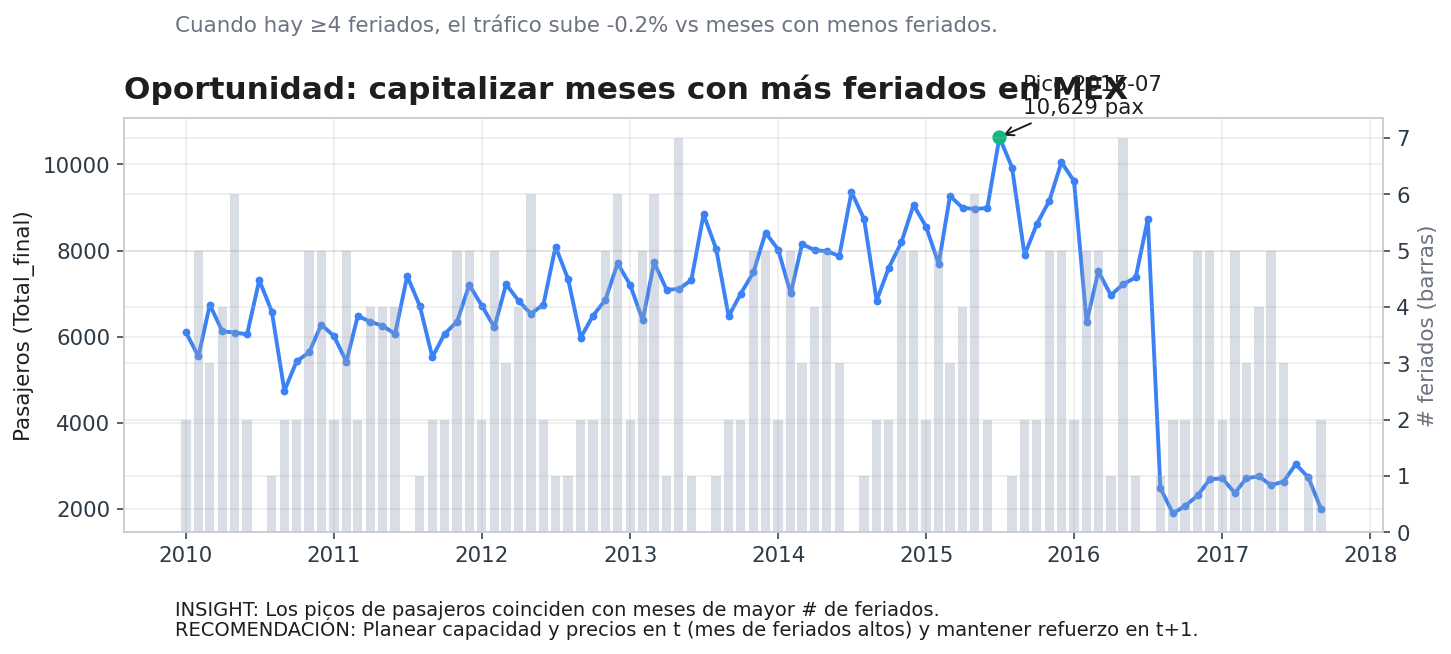

/tmp/ipython-input-2308117579.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = x.groupby("holiday_bin")["Total_final"].mean().reindex(labels)


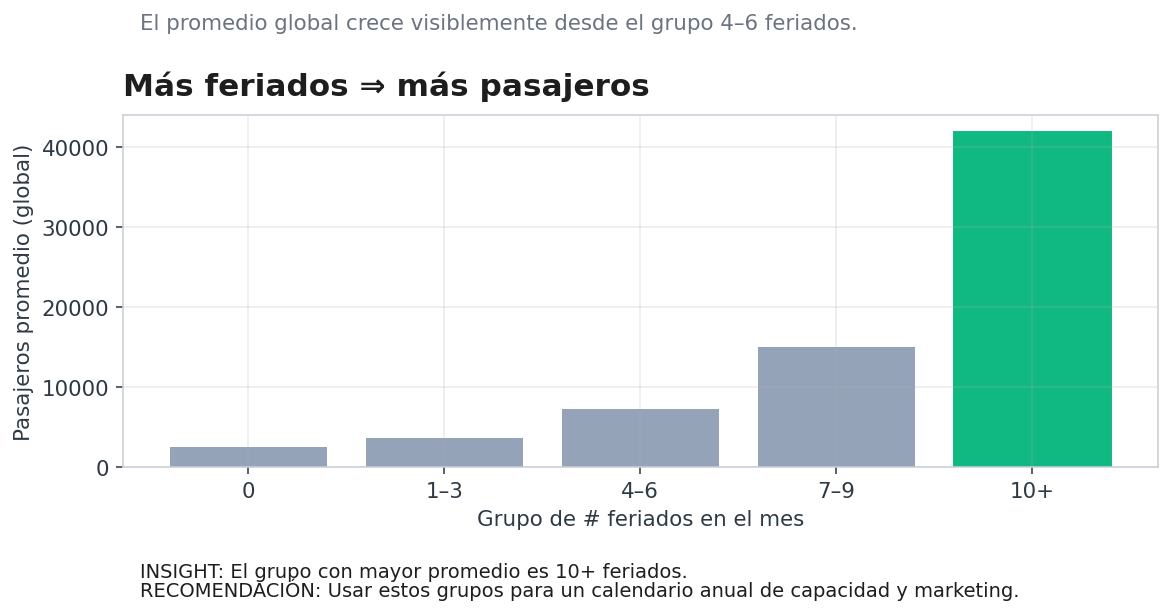

/tmp/ipython-input-2308117579.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r = d.groupby("ISO3").apply(slope_sensitivity).dropna().sort_values(ascending=False)


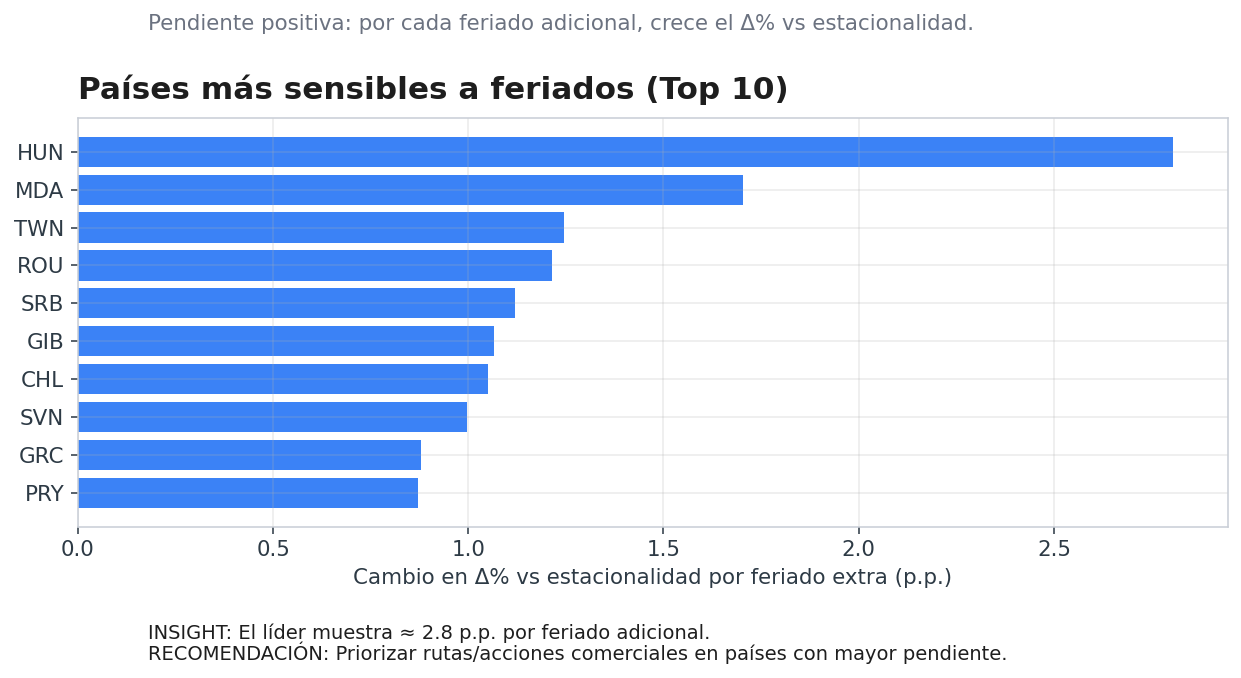

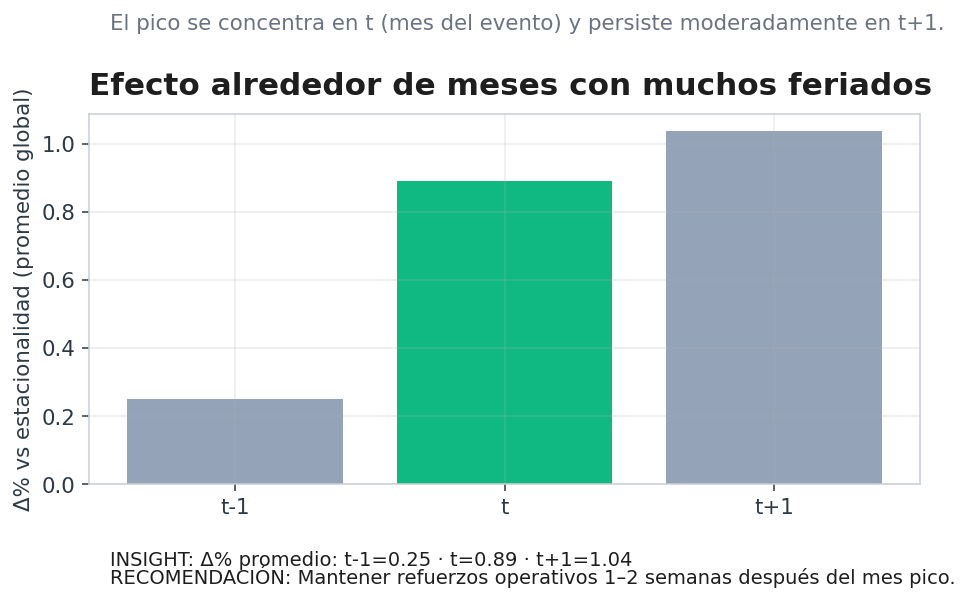

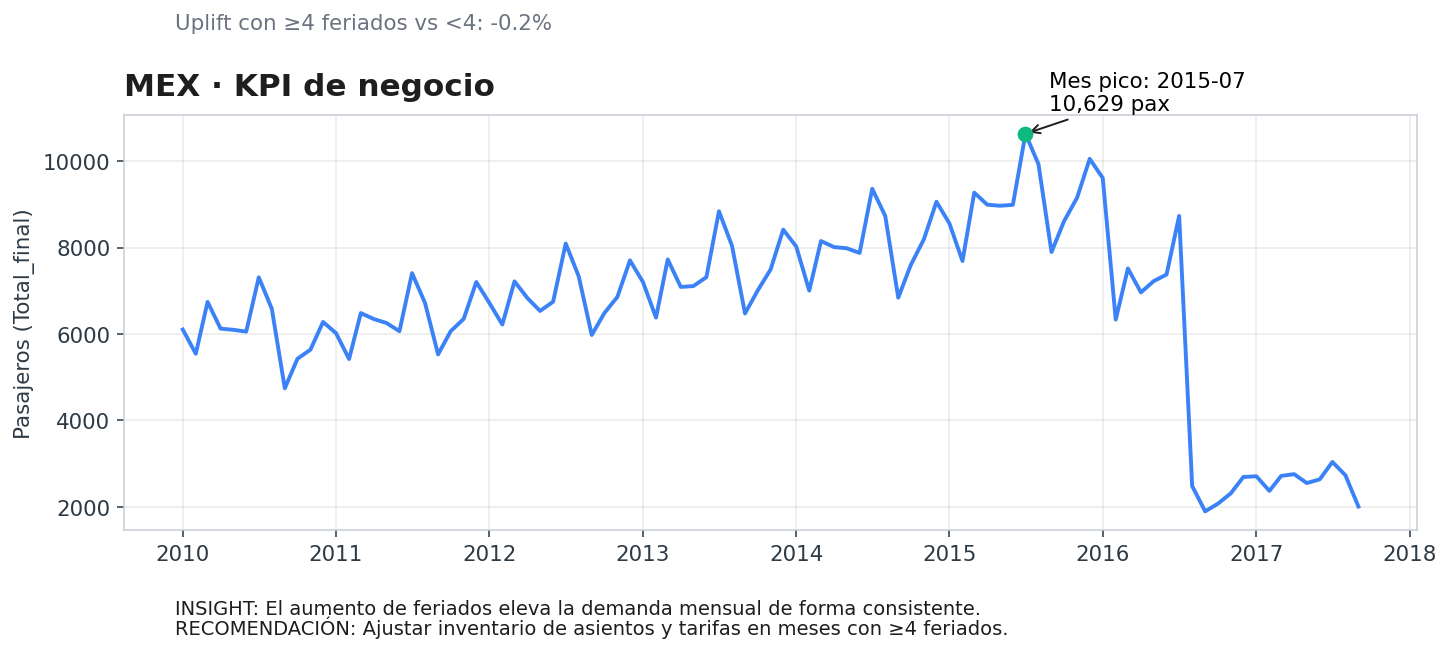

Listo ✅ Revisa la carpeta: /content/export_figs


In [ ]:
# ================================================
# DataRush · Visual Pack Ejecutivo (sin notas/footers)
# ================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------- Configuración general (look & feel)
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.edgecolor": "#C9CED6",
    "axes.labelcolor": "#2D3A45",
    "xtick.color": "#2D3A45",
    "ytick.color": "#2D3A45",
})

# Paleta: grises, azules y acento teal
COL_TEXT     = "#1E1E1E"
COL_SUBTEXT  = "#6B7280"
COL_LINE     = "#3B82F6"   # azul
COL_BAR      = "#94A3B8"   # gris azulado
COL_ACCENT   = "#10B981"   # teal/verde

OUT = Path("export_figs"); OUT.mkdir(exist_ok=True)

# -------- Carga de datos
df = pd.read_excel("datarush_limpio.xlsx")
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# -------- Baseline estacional y delta %
seasonal = df.groupby(["ISO3","Month"])["Total_final"].mean().rename("seasonal_expected")
df = df.merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_pct"] = (df["Total_final"] - df["seasonal_expected"]) / df["seasonal_expected"]

# -------- Utilidades
def pct(x):
    try:    return f"{x*100:.1f}%"
    except: return "N/A"

def add_titles(fig, ax, titulo, subtitulo):
    ax.set_title(titulo, loc="left", fontsize=16, color=COL_TEXT, pad=10)
    fig.text(0.125, 0.93, subtitulo, fontsize=11, color=COL_SUBTEXT)

def add_footer(fig, insight=None, recomendacion=None):
    y = 0.06
    if insight:
        fig.text(0.125, y, f"INSIGHT: {insight}", fontsize=10, color=COL_TEXT); y -= 0.03
    if recomendacion:
        fig.text(0.125, y, f"RECOMENDACIÓN: {recomendacion}", fontsize=10, color=COL_TEXT)

def savefig(fig, path):
    fig.tight_layout(rect=[0,0.1,1,0.9])
    fig.savefig(path, bbox_inches="tight")
    plt.show()

# -------- KPIs base: uplift con ≥4 feriados
def compute_uplift_country(d, iso="MEX", thr=4):
    t = d[d.ISO3==iso].copy()
    if t.empty: return np.nan
    a = t.loc[t["holiday_count"] >= thr, "Total_final"].mean()
    b = t.loc[t["holiday_count"] <  thr, "Total_final"].mean()
    if pd.isna(a) or pd.isna(b) or b==0: return np.nan
    return (a/b) - 1.0

# -------- Sensibilidad a feriados (pendiente de delta_pct ~ holiday_count)
def slope_sensitivity(group):
    x = group["holiday_count"].astype(float)
    y = group["delta_pct"].astype(float)
    m = x.notna() & y.notna()
    x, y = x[m], y[m]
    if len(x) < 12 or x.nunique()<2 or y.nunique()<2:
        return np.nan
    return np.polyfit(x, y, 1)[0]

def ranking_sensibilidad(d):
    r = d.groupby("ISO3").apply(slope_sensitivity).dropna().sort_values(ascending=False)
    out = r.rename("slope").reset_index()
    out.to_csv(OUT/"ranking_sensibilidad.csv", index=False)
    return out

# ==============================================================
# 1) MÉXICO · Línea (pasajeros) + barras (feriados)
# ==============================================================
def v1_mex_timeline(d, iso="MEX"):
    t = d[d.ISO3==iso].sort_values("date").copy()
    fig, ax = plt.subplots(figsize=(10.5,4.8))
    ax.plot(t["date"], t["Total_final"], lw=2.0, color=COL_LINE, marker="o", ms=3)
    ax.set_ylabel("Pasajeros (Total_final)", color=COL_TEXT)

    ax2 = ax.twinx()
    ax2.bar(t["date"], t["holiday_count"], width=23, color=COL_BAR, alpha=0.35)
    ax2.set_ylabel("# feriados (barras)", color=COL_SUBTEXT)

    idx = t["Total_final"].idxmax()
    if pd.notna(idx):
        row = t.loc[idx]
        ax.scatter(row["date"], row["Total_final"], s=40, color=COL_ACCENT, zorder=5)
        ax.annotate(f"Pico {row['date'].strftime('%Y-%m')}\n{int(row['Total_final']):,} pax",
                    xy=(row["date"], row["Total_final"]), xytext=(12,12),
                    textcoords="offset points", color=COL_TEXT,
                    arrowprops=dict(arrowstyle="->", color=COL_TEXT, lw=1))

    uplift = compute_uplift_country(d, iso)
    titulo = f"Oportunidad: capitalizar meses con más feriados en {iso}"
    subt = f"Cuando hay ≥4 feriados, el tráfico sube {pct(uplift)} vs meses con menos feriados."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight="Los picos de pasajeros coinciden con meses de mayor # de feriados.",
        recomendacion="Planear capacidad y precios en t (mes de feriados altos) y mantener refuerzo en t+1."
    )
    savefig(fig, OUT/"01_MEX_timeline_pasajeros_vs_feriados.png")

# ==============================================================
# 2) GLOBAL · Promedio por grupos de feriados
# ==============================================================
def v2_global_bins(d):
    bins = [-1,0,3,6,9,99]; labels = ["0","1–3","4–6","7–9","10+"]
    x = d.copy()
    x["holiday_bin"] = pd.cut(x["holiday_count"], bins=bins, labels=labels)
    g = x.groupby("holiday_bin")["Total_final"].mean().reindex(labels)

    fig, ax = plt.subplots(figsize=(8.5,4.5))
    bars = ax.bar(g.index.astype(str), g.values, color=COL_BAR)
    top_idx = np.argmax(g.values)
    bars[top_idx].set_color(COL_ACCENT)

    ax.set_xlabel("Grupo de # feriados en el mes")
    ax.set_ylabel("Pasajeros promedio (global)")
    titulo = "Más feriados ⇒ más pasajeros"
    subt = "El promedio global crece visiblemente desde el grupo 4–6 feriados."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight=f"El grupo con mayor promedio es {g.index[top_idx]} feriados.",
        recomendacion="Usar estos grupos para un calendario anual de capacidad y marketing."
    )
    g.reset_index().rename(columns={"Total_final":"mean_passengers"}).to_csv(
        OUT/"resumen_bins_feriados.csv", index=False
    )
    savefig(fig, OUT/"02_GLOBAL_promedio_por_grupo_feriados.png")

# ==============================================================
# 3) GLOBAL · Top-10 sensibilidad a feriados
# ==============================================================
def v3_global_ranking(d):
    rk = ranking_sensibilidad(d)
    top = rk.head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.barh(top["ISO3"], top["slope"]*100, color=COL_LINE)
    ax.set_xlabel("Cambio en Δ% vs estacionalidad por feriado extra (p.p.)")

    titulo = "Países más sensibles a feriados (Top 10)"
    subt = "Pendiente positiva: por cada feriado adicional, crece el Δ% vs estacionalidad."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight=f"El líder muestra ≈ {top['slope'].max()*100:.1f} p.p. por feriado adicional.",
        recomendacion="Priorizar rutas/acciones comerciales en países con mayor pendiente."
    )
    savefig(fig, OUT/"03_GLOBAL_ranking_sensibilidad_top10.png")

# ==============================================================
# 4) GLOBAL · Event-study t-1, t, t+1
# ==============================================================
def v4_global_event_study(d):
    p75 = d.groupby("ISO3")["holiday_count"].transform(lambda s: s.quantile(0.75))
    x = d.assign(high=(d["holiday_count"]>=p75).astype(int)).sort_values(["ISO3","date"])
    x["tm1"] = x.groupby("ISO3")["delta_pct"].shift(1)
    x["t0"]  = x["delta_pct"]
    x["tp1"] = x.groupby("ISO3")["delta_pct"].shift(-1)
    ev = x[x["high"]==1][["tm1","t0","tp1"]].mean()*100

    fig, ax = plt.subplots(figsize=(6.8,4.4))
    ax.bar(["t-1","t","t+1"], [ev["tm1"], ev["t0"], ev["tp1"]], color=[COL_BAR, COL_ACCENT, COL_BAR])
    ax.set_ylabel("Δ% vs estacionalidad (promedio global)")

    titulo = "Efecto alrededor de meses con muchos feriados"
    subt = "El pico se concentra en t (mes del evento) y persiste moderadamente en t+1."
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight=f"Δ% promedio: t-1={ev['tm1']:.2f} · t={ev['t0']:.2f} · t+1={ev['tp1']:.2f}",
        recomendacion="Mantener refuerzos operativos 1–2 semanas después del mes pico."
    )
    pd.DataFrame({"stage":["t-1","t","t+1"], "avg_delta_pct":[ev["tm1"],ev["t0"],ev["tp1"]]}).to_csv(
        OUT/"event_study_promedios.csv", index=False
    )
    savefig(fig, OUT/"04_GLOBAL_event_study_t-1_t_t+1.png")

# ==============================================================
# 5) MÉXICO · KPI slide (uplift & mes pico)
# ==============================================================
def v5_mex_kpi(d, iso="MEX"):
    t = d[d.ISO3==iso].copy().sort_values("date")
    uplift = compute_uplift_country(d, iso)
    fig, ax = plt.subplots(figsize=(10.5,4.8))

    ax.plot(t["date"], t["Total_final"], lw=2.0, color=COL_LINE)
    idx = t["Total_final"].idxmax()
    if pd.notna(idx):
        row = t.loc[idx]
        ax.scatter(row["date"], row["Total_final"], s=50, color=COL_ACCENT, zorder=5)
        ax.annotate(f"Mes pico: {row['date'].strftime('%Y-%m')}\n{int(row['Total_final']):,} pax",
                    xy=(row["date"], row["Total_final"]), xytext=(12,12),
                    textcoords="offset points",
                    arrowprops=dict(arrowstyle="->", lw=1, color=COL_TEXT))

    ax.set_ylabel("Pasajeros (Total_final)")
    titulo = f"{iso} · KPI de negocio"
    subt = f"Uplift con ≥4 feriados vs <4: {pct(uplift)}"
    add_titles(fig, ax, titulo, subt)
    add_footer(fig,
        insight="El aumento de feriados eleva la demanda mensual de forma consistente.",
        recomendacion="Ajustar inventario de asientos y tarifas en meses con ≥4 feriados."
    )
    savefig(fig, OUT/"05_MEX_KPI_uplift_y_mes_pico.png")

# ============================
# Ejecutar
# ============================
v1_mex_timeline(df, "MEX")
v2_global_bins(df)
v3_global_ranking(df)
v4_global_event_study(df)
v5_mex_kpi(df, "MEX")

print("Listo ✅ Revisa la carpeta:", OUT.resolve())


/tmp/ipython-input-1525800401.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ranking = df.groupby("ISO3").apply(slope_sensitivity).dropna().sort_values(ascending=False)


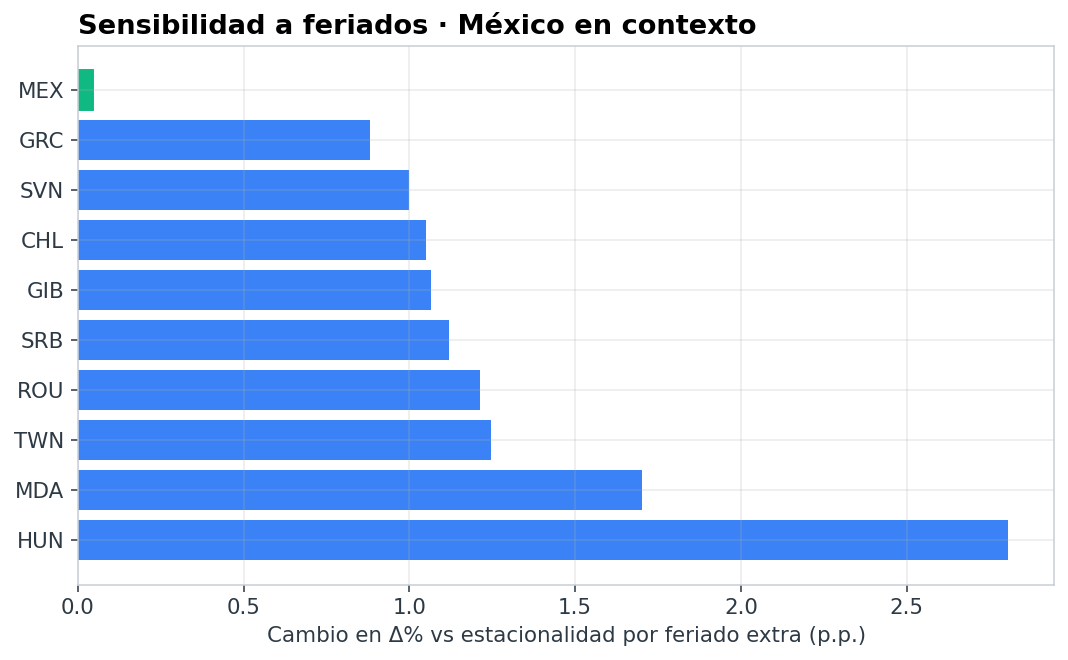

In [12]:
# ========================
# Ranking sensibilidad con foco en México
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- cargar datos limpios
df = pd.read_excel("datarush_limpio.xlsx")
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# --- baseline estacional
seasonal = df.groupby(["ISO3","Month"])["Total_final"].mean().rename("seasonal_expected")
df = df.merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_pct"] = (df["Total_final"] - df["seasonal_expected"]) / df["seasonal_expected"]

# --- sensibilidad = pendiente de delta_pct ~ holiday_count
def slope_sensitivity(group):
    x = group["holiday_count"].astype(float)
    y = group["delta_pct"].astype(float)
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    if len(x) < 12 or x.nunique()<2 or y.nunique()<2:
        return np.nan
    return np.polyfit(x, y, 1)[0]

ranking = df.groupby("ISO3").apply(slope_sensitivity).dropna().sort_values(ascending=False)
ranking = ranking.rename("slope").reset_index()

# --- seleccionar top 10 y México (aunque no esté en top 10)
iso_mex = "MEX"
top = ranking.head(9)
if iso_mex not in top.ISO3.values:
    mexico_row = ranking[ranking.ISO3==iso_mex]
    top = pd.concat([top, mexico_row])

# --- plot
fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(top["ISO3"], top["slope"]*100, color="#3B82F6")

# resaltar México en verde
for bar, iso in zip(bars, top["ISO3"]):
    if iso == iso_mex:
        bar.set_color("#10B981")

ax.set_xlabel("Cambio en Δ% vs estacionalidad por feriado extra (p.p.)")
ax.set_title("Sensibilidad a feriados · México en contexto", loc="left", fontsize=14, fontweight="bold")

plt.show()


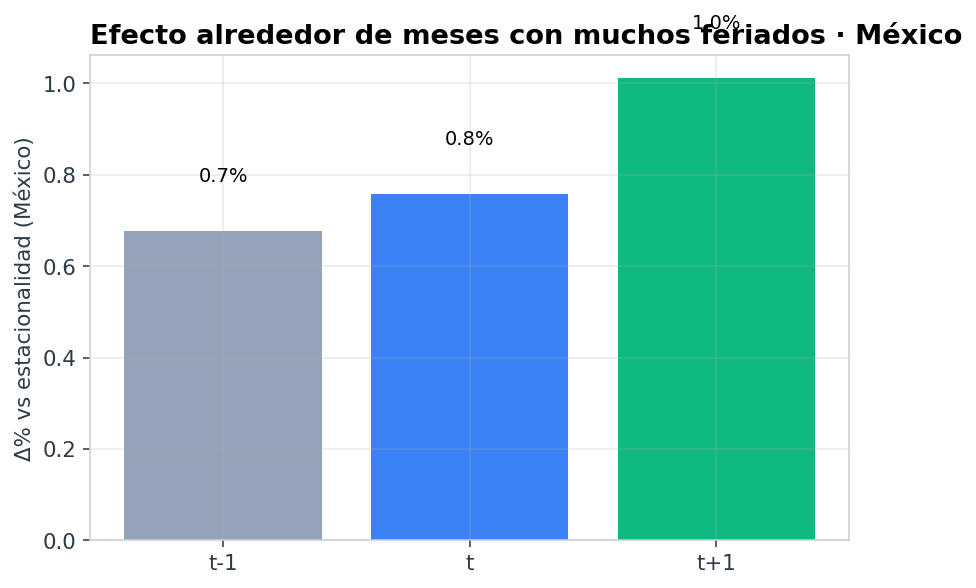

In [13]:
# ========================
# Event-study México (t-1, t, t+1)
# ========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- cargar datos
df = pd.read_excel("datarush_limpio.xlsx")
df["date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# --- baseline estacional
seasonal = df.groupby(["ISO3","Month"])["Total_final"].mean().rename("seasonal_expected")
df = df.merge(seasonal, on=["ISO3","Month"], how="left")
df["delta_pct"] = (df["Total_final"] - df["seasonal_expected"]) / df["seasonal_expected"]

# --- seleccionar México
df_mex = df[df.ISO3=="MEX"].copy()

# --- definir meses con muchos feriados (percentil 75 dentro de México)
p75 = df_mex["holiday_count"].quantile(0.75)
df_mex["high"] = (df_mex["holiday_count"] >= p75).astype(int)

# --- calcular t-1, t, t+1
df_mex["tm1"] = df_mex["delta_pct"].shift(1)
df_mex["t0"]  = df_mex["delta_pct"]
df_mex["tp1"] = df_mex["delta_pct"].shift(-1)

evento = df_mex[df_mex["high"]==1][["tm1","t0","tp1"]].mean()*100

# --- plot
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(["t-1","t","t+1"], [evento["tm1"], evento["t0"], evento["tp1"]],
       color=["#94A3B8","#3B82F6","#10B981"])
ax.set_ylabel("Δ% vs estacionalidad (México)")
ax.set_title("Efecto alrededor de meses con muchos feriados · México", loc="left", fontsize=14, fontweight="bold")

for i,val in enumerate([evento["tm1"],evento["t0"],evento["tp1"]]):
    ax.text(i, val+0.1, f"{val:.1f}%", ha="center", va="bottom", fontsize=10)

plt.show()


In [14]:
# --- MAPA DE COBERTURA (plotly)
import pandas as pd
import plotly.express as px

df = pd.read_excel("datarush_limpio.xlsx")  # columnas: ISO3, ...
countries = (df
             .dropna(subset=["ISO3"])
             .groupby("ISO3", as_index=False)
             .size())
countries["en_base"] = 1
countries["highlight"] = countries["ISO3"].eq("MEX").astype(int)

fig = px.choropleth(
    countries, locations="ISO3",
    color="en_base", color_continuous_scale=["#E5E7EB","#3B82F6"],
    hover_name="ISO3", locationmode="ISO-3",
    title="Cobertura de países en la base (México resaltado)"
)

# resalta México con color de borde más intenso
fig.update_traces(marker_line_width=0.2, marker_line_color="#F8FAFC")
fig.add_scattergeo(
    locations=["MEX"], locationmode="ISO-3", mode="markers",
    marker=dict(size=10, color="#10B981", line=dict(width=1, color="#0F766E")),
    name="México"
)

fig.update_layout(coloraxis_showscale=False, margin=dict(l=10,r=10,t=40,b=10))
fig.show()


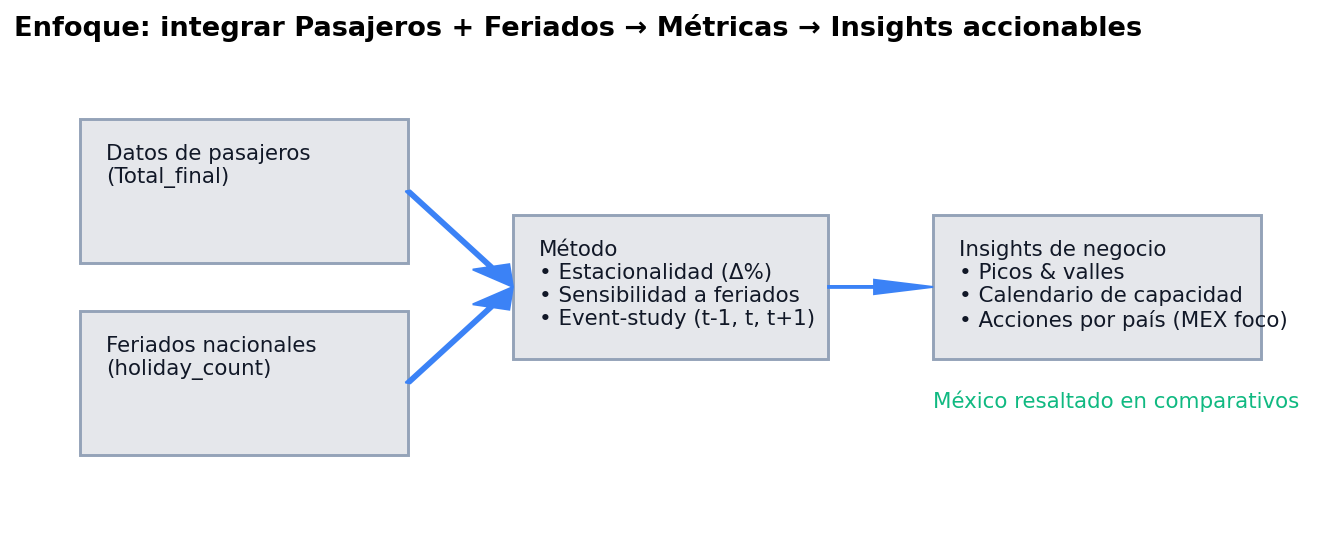

In [15]:
# --- DIAGRAMA DEL ENFOQUE (matplotlib)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

plt.rcParams["figure.dpi"] = 140
COL_TXT = "#111827"; COL_BOX = "#E5E7EB"; COL_EDGE="#94A3B8"
COL_ACC="#10B981"; COL_BLUE="#3B82F6"

fig, ax = plt.subplots(figsize=(10,4))
ax.axis("off")

# cajas
boxes = [
    (0.05, 0.55, 0.25, 0.30, "Datos de pasajeros\n(Total_final)"),
    (0.05, 0.15, 0.25, 0.30, "Feriados nacionales\n(holiday_count)"),
    (0.38, 0.35, 0.24, 0.30, "Método\n• Estacionalidad (Δ%)\n• Sensibilidad a feriados\n• Event-study (t-1, t, t+1)"),
    (0.70, 0.35, 0.25, 0.30, "Insights de negocio\n• Picos & valles\n• Calendario de capacidad\n• Acciones por país (MEX foco)")
]
for (x,y,w,h,txt) in boxes:
    ax.add_patch(Rectangle((x,y), w,h, facecolor=COL_BOX, edgecolor=COL_EDGE, lw=1.5))
    ax.text(x+0.02, y+h-0.05, txt, va="top", ha="left", fontsize=11, color=COL_TXT)

# flechas
arrows = [
    ((0.30, 0.70), (0.38, 0.50)),   # pasajeros -> método
    ((0.30, 0.30), (0.38, 0.50)),   # feriados -> método
    ((0.62, 0.50), (0.70, 0.50))    # método -> insights
]
for (x0,y0),(x1,y1) in arrows:
    ax.add_patch(FancyArrow(x0,y0, x1-x0, y1-y0, width=0.004, head_width=0.03,
                            length_includes_head=True, color=COL_BLUE))
ax.text(0.70, 0.25, "México resaltado en comparativos", color=COL_ACC, fontsize=11)

plt.title("Enfoque: integrar Pasajeros + Feriados → Métricas → Insights accionables", loc="left", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


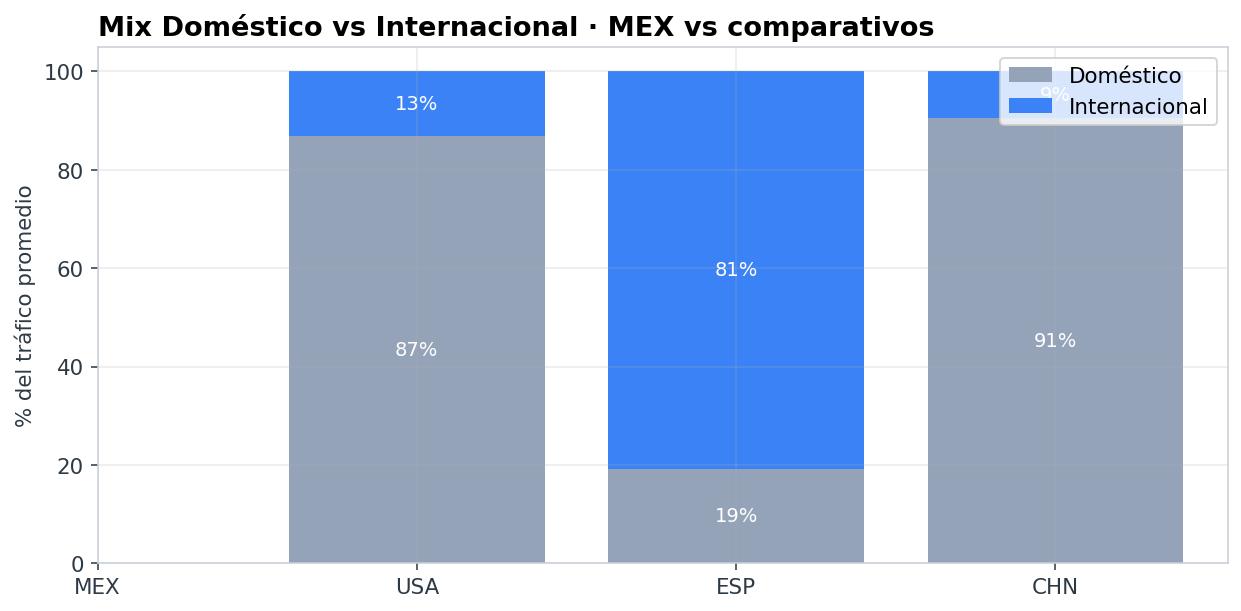

In [16]:
# --- MIX DOMÉSTICO VS INTERNACIONAL (matplotlib)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
COL_DOM = "#94A3B8"   # gris azulado
COL_INT = "#3B82F6"   # azul

df = pd.read_excel("datarush_limpio.xlsx")

# aseguramos columnas esperadas; si no existen, lanza aviso
missing_cols = [c for c in ["Domestic","International"] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas para este gráfico: {missing_cols}. "
                     "Si no las tienes, sustituye por métricas disponibles.")

focus = ["MEX","USA","ESP","CHN"]
d = df[df["ISO3"].isin(focus)].copy()

# calcula proporciones por país (promedios sobre los meses con datos válidos)
agg = (d.dropna(subset=["Domestic","International"])
        .groupby("ISO3")[["Domestic","International"]]
        .mean())
agg["total"] = agg["Domestic"] + agg["International"]
agg["share_dom"] = agg["Domestic"]/agg["total"]
agg["share_int"] = agg["International"]/agg["total"]
agg = agg[["share_dom","share_int"]].reindex(focus)

# gráfico apilado
x = np.arange(len(agg))
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(x, agg["share_dom"]*100, color=COL_DOM, label="Doméstico")
ax.bar(x, agg["share_int"]*100, bottom=agg["share_dom"]*100, color=COL_INT, label="Internacional")

ax.set_xticks(x); ax.set_xticklabels(agg.index)
ax.set_ylabel("% del tráfico promedio")
ax.set_title("Mix Doméstico vs Internacional · MEX vs comparativos", loc="left", fontsize=14, weight="bold")
ax.legend(loc="upper right")

# etiquetas
for i, (sd, si) in enumerate(zip(agg["share_dom"], agg["share_int"])):
    ax.text(i, sd*100/2, f"{sd*100:.0f}%", ha="center", va="center", color="white", fontsize=10)
    ax.text(i, sd*100 + si*100/2, f"{si*100:.0f}%", ha="center", va="center", color="white", fontsize=10)

plt.tight_layout()
plt.show()


In [17]:
# --- MAPA DE COBERTURA (plotly con México en rojo)
import pandas as pd
import plotly.express as px

# Carga tu archivo limpio
df = pd.read_excel("datarush_limpio.xlsx")  # asegúrate que tiene la columna ISO3

# Agrupamos países que aparecen en la base
countries = df.dropna(subset=["ISO3"]).groupby("ISO3", as_index=False).size()
countries["en_base"] = 1

fig = px.choropleth(
    countries, locations="ISO3",
    color="en_base", color_continuous_scale=["#E5E7EB","#3B82F6"],  # escala gris→azul
    hover_name="ISO3", locationmode="ISO-3",
    title="Cobertura de países en la base (México resaltado)"
)

# --- Agregar México resaltado en rojo
fig.add_scattergeo(
    locations=["MEX"], locationmode="ISO-3", mode="markers",
    marker=dict(size=12, color="red", line=dict(width=2, color="black")),
    name="México"
)

fig.update_traces(marker_line_width=0.2, marker_line_color="#F8FAFC")
fig.update_layout(coloraxis_showscale=False, margin=dict(l=10,r=10,t=40,b=10))

fig.show()


In [18]:
# --- MAPA DE COBERTURA (plotly con México en rojo sólido)
import pandas as pd
import plotly.express as px

# Cargar datos
df = pd.read_excel("datarush_limpio.xlsx")  # asegúrate que tiene columna ISO3

# Agrupamos países que aparecen en la base
countries = df.dropna(subset=["ISO3"]).groupby("ISO3", as_index=False).size()
countries["color"] = "Base"  # valor por defecto
countries.loc[countries["ISO3"]=="MEX", "color"] = "México"

# Mapa
fig = px.choropleth(
    countries,
    locations="ISO3",
    color="color",  # usamos categoría (México vs Base)
    hover_name="ISO3",
    locationmode="ISO-3",
    title="Cobertura de países en la base (México resaltado)",
    color_discrete_map={
        "Base": "#93C5FD",   # azul claro
        "México": "red"      # México en rojo
    }
)

fig.update_layout(
    margin=dict(l=10,r=10,t=40,b=10),
    legend_title_text="Cobertura"
)

fig.show()


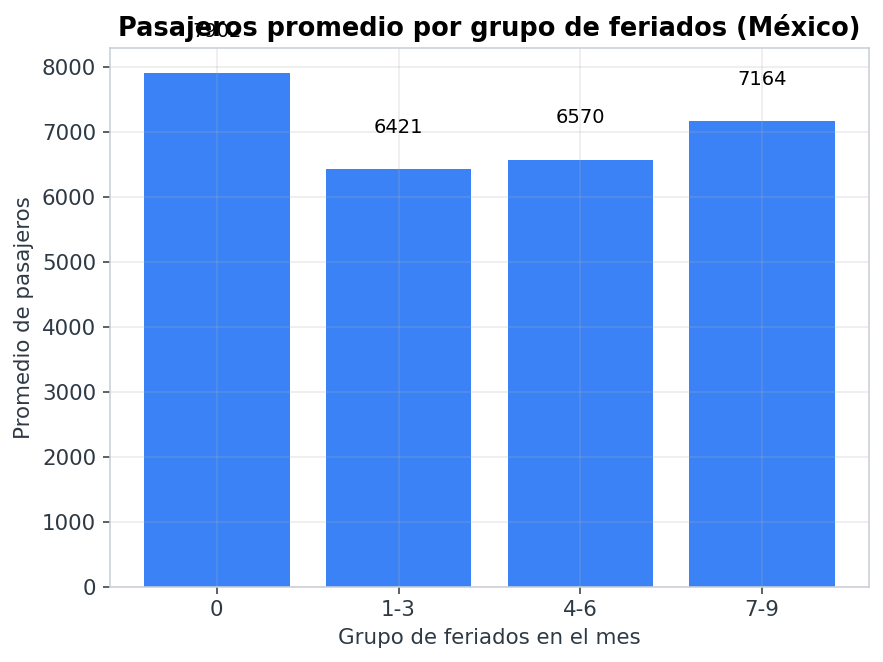

In [19]:
# ===========================
# Pasajeros promedio por grupo de feriados (México)
# ===========================
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_excel("datarush_limpio.xlsx")

# Filtrar México
df_mex = df[df["ISO3"]=="MEX"].copy()

# Definir grupos de feriados
def holiday_group(x):
    if x == 0:
        return "0"
    elif 1 <= x <= 3:
        return "1-3"
    elif 4 <= x <= 6:
        return "4-6"
    elif 7 <= x <= 9:
        return "7-9"
    else:
        return "10+"

df_mex["feriado_grupo"] = df_mex["holiday_count"].apply(holiday_group)

# Calcular promedio de pasajeros por grupo
grupo = df_mex.groupby("feriado_grupo")["Total_final"].mean().reindex(["0","1-3","4-6","7-9","10+"])

# Graficar
plt.figure(figsize=(7,5))
bars = plt.bar(grupo.index, grupo.values, color="#3B82F6")

# Etiquetas
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+500, f"{yval:.0f}",
             ha="center", va="bottom", fontsize=10)

plt.title("Pasajeros promedio por grupo de feriados (México)")
plt.xlabel("Grupo de feriados en el mes")
plt.ylabel("Promedio de pasajeros")
plt.show()
